# 2c. Natural Gas Meta-Model
### Natural Gas Futures (ng1s)

In this notebook we develop the meta-model for natural gas (ng1s). Meta-labelling uses a secondary model to decide whether to act on a primary model's signal. The primary signal says which way to trade, and the meta-model gives each of those signals a probability of being a genuine opportunity rather than noise.

We start from the assembled feature matrix built in notebook 1, which gives every instrument a common set of base features. On top of that we add a few natural gas specific features, the latent regime features, and the primary-signal features, then reduce everything with PCA, label the trades with the triple-barrier method, and compare a range of models. Every feature is strictly backward looking, so nothing here uses information from the future.

**Models compared (Section 9):** Logistic Regression (L2-regularised), Random Forest, XGBoost, MLP, Variable Selection Network, and LSTM, each hyperparameter-tuned and ranked by walk-forward cross-validation AUC. **Winning model: Logistic Regression** (selected in Section 11). Its probabilities are the exported deliverable.

## 1. Imports

We load the standard scientific Python stack together with scikit-learn, XGBoost and Keras. These cover the data handling, the classical models, and the neural networks used later on.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline

from hmmlearn.hmm import GaussianHMM

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import xgboost as xgb

# --- Reproducibility: pin threads BEFORE importing numpy / tensorflow ---
# Once every RNG is seeded, the main remaining source of run-to-run drift is
# thread-level floating-point summation order (BLAS, OpenMP, XGBoost, TF).
# These env vars must be set before numpy/tf are imported.
import os
os.environ["PYTHONHASHSEED"]         = "42"
os.environ["OMP_NUM_THREADS"]        = "1"
os.environ["OPENBLAS_NUM_THREADS"]   = "1"
os.environ["MKL_NUM_THREADS"]        = "1"
os.environ["NUMEXPR_NUM_THREADS"]    = "1"
os.environ["TF_NUM_INTEROP_THREADS"] = "1"
os.environ["TF_NUM_INTRAOP_THREADS"] = "1"
os.environ["TF_DETERMINISTIC_OPS"]   = "1"

import random
import numpy as np
import tensorflow as tf
from tensorflow import keras

# single-threaded TF (belt-and-braces alongside the env vars above)
tf.config.threading.set_intra_op_parallelism_threads(1)
tf.config.threading.set_inter_op_parallelism_threads(1)

# seed every RNG to one value
random.seed(42)
np.random.seed(42)
keras.utils.set_random_seed(42)            # Python + NumPy + TensorFlow
tf.config.experimental.enable_op_determinism()


## 2. Load the Feature Matrix

We load the assembled feature matrix and, for natural gas, add the more specific data on top before running the triple-barrier method and the HMM for the regime state. The base features were built in the feature engineering notebook, and the idea is to keep a common set of base features that we can then enrich, so the meta-model has both general and natural gas specific information to work with.

In [2]:
features = pd.read_parquet('../data/processed/features/features.parquet')
features['date'] = pd.to_datetime(features['date'])
feat_dict = pd.read_csv('../data/processed/features/feature_dictionary.csv')

print('Shape:', features.shape)
print('Date range:', features['date'].min().date(), '→', features['date'].max().date())
print('Instruments:', sorted(features['instrument'].unique()))
print('Feature columns:', len(features.columns) - 3)  # minus date, instrument, primary_signal

Shape: (2512, 63)
Date range: 2020-01-03 → 2022-06-30
Instruments: ['cl1s', 'ho1s', 'ng1s', 'rb1s']
Feature columns: 60


## 3. Tier 1: Base Features

We keep the natural gas rows (ng1s), sort them by date, and recap the Tier 1 base features. These are the general price and volatility features that apply to any instrument, such as returns, momentum, rolling volatility, and the trend-scanning t-statistics. They describe what prices have actually done and form the backbone that the later tiers build on.

In [3]:
natural_gas = features[features['instrument'] == 'ng1s'].set_index('date').sort_index().copy()
print(natural_gas.shape)
natural_gas.head()

(628, 62)


,instrument,primary_signal,ret_1d,logret_1d,ret_5d,ret_10d,ret_20d,ret_60d,vol_20d,vol_60d,...,hmm_filt_calm,hmm_filt_turbulent,hmm_next_turbulent,hmm_regime_age,hmm_basket_turbulent_energy,kmeans_cluster_id,kmeans_cluster_size,primary_signal_lag1,primary_signal_lag5,primary_signal_streak
date,,,,,,,,,,,,,,,,,,,,,
2020-01-03,ng1s,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-06,ng1s,0.0,0.003768,0.003761,-0.070245,-0.062920,-0.111169,-0.146598,0.025074,0.027664,...,0.509833,0.490167,0.488715,0.0,0.998434,2.0,0.25,NaN,NaN,0.0
2020-01-07,ng1s,0.0,0.002348,0.002345,-0.043985,-0.054870,-0.120427,-0.120370,0.024825,0.027526,...,0.850642,0.149358,0.157477,1.0,0.999299,1.0,0.50,0.0,NaN,1.0
2020-01-08,ng1s,0.0,0.012646,0.012566,-0.011041,-0.066216,-0.068789,-0.100614,0.023874,0.027581,...,0.971416,0.028584,0.040094,2.0,0.999323,1.0,0.25,0.0,NaN,2.0
2020-01-09,ng1s,0.0,-0.009713,-0.009761,-0.022171,-0.034883,-0.033864,-0.108571,0.021893,0.027601,...,0.996059,0.003941,0.016143,3.0,0.985763,0.0,1.00,0.0,NaN,3.0


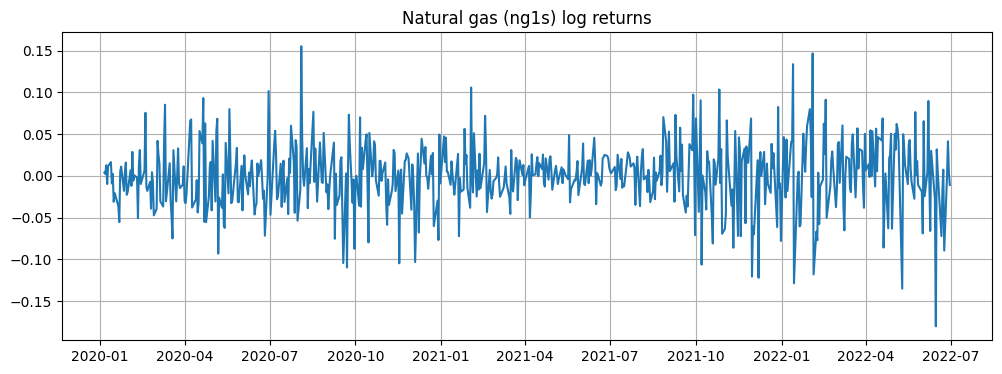

In [4]:
plt.figure(figsize=(12, 4))
plt.plot(natural_gas.index, natural_gas['logret_1d'])
plt.title('Natural gas (ng1s) log returns')
plt.grid(True)
plt.show()

In [5]:
base_cols = [
    'logret_1d', 'ret_5d', 'ret_10d', 'ret_20d', 'ret_60d',
    'vol_20d', 'vol_60d', 'parkinson_20d', 'garman_klass_20d',
    'vol_of_vol_20d', 'vol_ratio_5_60',
    'volume_z_20d', 'oi_z_60d', 'oi_change_5d', 'volume_oi_ratio',
    'rsi_14', 'macd', 'macd_signal', 'macd_hist',
    'bb_width_20', 'bb_pos_20', 'atr_14', 'adx_14',
    'dd_from_60d_high', 'runup_from_60d_low', 'days_since_60d_high',
    'trend_tstat_10', 'trend_tstat_20', 'trend_tstat_60',
    'trend_tstat_best', 'trend_H_best',
]
natural_gas[base_cols].tail()

,logret_1d,ret_5d,ret_10d,ret_20d,ret_60d,vol_20d,vol_60d,parkinson_20d,garman_klass_20d,vol_of_vol_20d,...,atr_14,adx_14,dd_from_60d_high,runup_from_60d_low,days_since_60d_high,trend_tstat_10,trend_tstat_20,trend_tstat_60,trend_tstat_best,trend_H_best
date,,,,,,,,,,,,,,,,,,,,,
2022-06-24,-0.089608,-0.168369,-0.327399,-0.343025,0.092707,0.058946,0.053085,0.057527,0.056566,0.006880,...,0.000392,25.082368,-0.327376,0.139957,12.0,-7.274126,-5.509507,5.660811,-7.274126,10.0
2022-06-27,-0.000320,-0.174602,-0.357616,-0.360957,0.130671,0.058524,0.052828,0.057236,0.056183,0.007038,...,0.000378,26.186247,-0.327591,0.083679,13.0,-6.525403,-6.084316,4.481490,-6.525403,10.0
2022-06-28,0.041326,-0.061063,-0.303602,-0.308675,0.121688,0.060007,0.052702,0.057047,0.055382,0.007262,...,0.000373,26.763738,-0.299221,0.121997,14.0,-4.913552,-6.541973,3.605384,-6.541973,20.0
2022-06-29,0.003659,-0.037626,-0.272334,-0.285949,0.118769,0.060149,0.052699,0.056625,0.054751,0.007454,...,0.000360,26.970030,-0.296652,0.112307,15.0,-4.411730,-7.022739,2.812396,-7.022739,20.0
2022-06-30,-0.011019,-0.055962,-0.103097,-0.227950,0.094019,0.058754,0.052703,0.055886,0.054921,0.007571,...,0.000352,26.936075,-0.304360,0.100117,16.0,-4.071191,-8.725682,2.051639,-8.725682,20.0


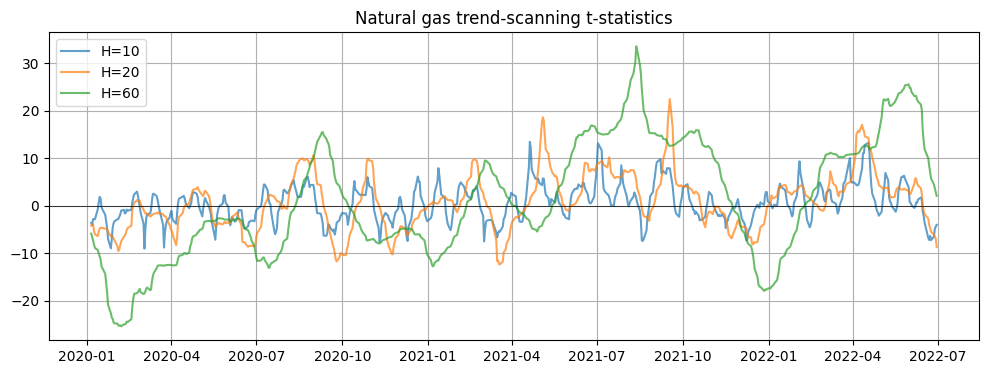

In [6]:
# Trend-scanning t-stats, Lecture 1, max |t| over several horizons
fig, ax = plt.subplots(figsize=(12, 4))
for h in [10, 20, 60]:
    ax.plot(natural_gas.index, natural_gas[f'trend_tstat_{h}'], label=f'H={h}', alpha=0.7)
ax.axhline(0, color='k', lw=0.5)
ax.set_title('Natural gas trend-scanning t-statistics')
ax.legend()
ax.grid(True)
plt.show()

## 4. Tier 2: Energy-Specific Features

Tier 2 adds features that are specific to the energy complex, for example crack spreads and cross-instrument spreads. Meta-labelling uses a secondary model to decide whether to act on the primary model's signal, and these features give that secondary model the energy-market context that a generic price feature would miss.

In [7]:
energy_cols = [
    'energy_basket_ret_5d', 'energy_basket_vol_20d',
    'rel_ret_vs_basket_5d', 'corr_to_basket_60d',
    'crack_321_proxy', 'crack_321_z_60d',
    'ho_cl_spread', 'rb_cl_spread',
    'month_sin', 'month_cos', 'dow_sin', 'dow_cos',
    'winter_indicator', 'driving_season',
]
natural_gas[energy_cols].tail()

,energy_basket_ret_5d,energy_basket_vol_20d,rel_ret_vs_basket_5d,corr_to_basket_60d,crack_321_proxy,crack_321_z_60d,ho_cl_spread,rb_cl_spread,month_sin,month_cos,dow_sin,dow_cos,winter_indicator,driving_season
date,,,,,,,,,,,,,,
2022-06-24,-0.082644,0.031510,-0.085725,0.704117,0.000829,-0.164069,-2.127562,-1.151850,1.224647e-16,-1.0,-0.587785,-0.809017,0.0,1.0
2022-06-27,-0.076530,0.031862,-0.098071,0.698289,-0.007808,-0.653094,-2.152614,-1.151036,1.224647e-16,-1.0,-0.951057,0.309017,0.0,1.0
2022-06-28,-0.014179,0.032228,-0.046884,0.690462,-0.035379,-2.143010,-2.200607,-1.180108,1.224647e-16,-1.0,0.000000,1.000000,0.0,1.0
2022-06-29,-0.001454,0.032284,-0.036172,0.706217,-0.001817,-0.235772,-2.221490,-1.172391,1.224647e-16,-1.0,0.951057,0.309017,0.0,1.0
2022-06-30,-0.025822,0.032777,-0.030140,0.702401,-0.016514,-1.046729,-2.242871,-1.186471,1.224647e-16,-1.0,0.587785,-0.809017,0.0,1.0


### 4.1 OVX Implied-Volatility Features

OVX is the CBOE Crude Oil Volatility Index, the oil-market analogue of VIX. Natural gas has its own volatility drivers but trades inside the same energy complex, so we use OVX as a broad forward-looking gauge of energy-market volatility, useful alongside the backward-looking `vol_20d`, `parkinson_20d`, and related features.

In this section we compute the following:
- `ovx_close` daily close
- `ovx_z` z-score on a 63-day window
- `iv_rv_ratio` implied vol (OVX) divided by realised vol (20-day annualised, in vol points)
- `ovx_slope` 5-day percentage change

**Why these features matter for meta-labelling**

The core idea is that options markets price in information that price-based features miss. When OVX is elevated, the market is paying up for crash protection, which usually means someone knows something or at least fears something. That is exactly the regime where a trend-following primary signal is most likely to get whipsawed.

`ovx_close` gives the raw implied vol level. On its own it is noisy, but it tells the meta-model whether the market is broadly calm or stressed. A bullish natural gas signal fired into a 50 plus OVX reading deserves a lot more scepticism than the same signal at OVX 25.

`ovx_z` normalises that level against the past 63 days. An OVX of 35 is unremarkable in a high-vol year but extreme in a quiet one. The z-score is what tells the meta-model whether the market is unusually fearful relative to its recent baseline, which is the number that matters for confidence calibration.

`iv_rv_ratio` is the most informative of the four. When implied vol runs well above realised vol, options are expensive and the market is pricing in a jump that has not happened yet. That tends to mean either a real catalyst is coming or the market is being irrational, and either way signal quality drops. When IV is below RV, options are cheap, the market has stopped hedging, and price action tends to be cleaner and more trend-friendly. The ratio is a direct read on how much the market trusts its own price signals.

`ovx_slope` captures whether fear is building or fading. A sharply rising OVX over 5 days, even from a moderate level, often precedes the kind of volatile, choppy price action that kills quantitative signals. A falling OVX after a spike is the opposite, the market is calming down and directional signals start working again. The slope gives the meta-model a sense of direction, not just level.

In [8]:
def load_ovx():
    """Return OVX close series indexed by date, or None if unavailable."""
    local = '../data/src/ovx.csv'
    df = pd.read_csv(local)
    date_col = 'Date' if 'Date' in df.columns else 'date'
    close_col = 'Close' if 'Close' in df.columns else 'close'
    df[date_col] = pd.to_datetime(df[date_col])
    return df.set_index(date_col)[close_col].rename('ovx_close').sort_index()


ovx_close = load_ovx()
if ovx_close is not None:
    ovx_close.index = pd.to_datetime(ovx_close.index).tz_localize(None)
    print('OVX rows:', len(ovx_close),
          'range:', ovx_close.index.min().date(), '→', ovx_close.index.max().date())
else:
    print('No OVX data available, subsequent OVX cells will be skipped.')

OVX rows: 4789 range: 2007-05-10 → 2026-05-21


In [9]:
if ovx_close is not None:
    ovx = ovx_close.to_frame()
    ovx['ovx_z'] = (
        (ovx['ovx_close'] - ovx['ovx_close'].rolling(63).mean())
        / ovx['ovx_close'].rolling(63).std()
    )
    ovx['ovx_slope'] = ovx['ovx_close'].pct_change(5)

    # iv_rv_ratio: implied (OVX, already in annualised vol points) over realised.
    # vol_20d is the std of daily logret, annualise by sqrt(252) and scale by 100 for vol points.
    rv_pts = natural_gas['vol_20d'] * np.sqrt(252) * 100
    ovx['iv_rv_ratio'] = ovx['ovx_close'] / rv_pts.reindex(ovx.index)

    natural_gas = natural_gas.join(ovx[['ovx_close', 'ovx_z', 'iv_rv_ratio', 'ovx_slope']], how='left')
    print(natural_gas[['ovx_close', 'ovx_z', 'iv_rv_ratio', 'ovx_slope']].dropna().tail())
else:
    print('Skipped: OVX not loaded.')

            ovx_close     ovx_z  iv_rv_ratio  ovx_slope
date                                                   
2022-06-24  46.990002 -0.948578     0.502170   0.015561
2022-06-27  46.990002 -0.974712     0.505789  -0.044724
2022-06-28  46.590000 -1.102164     0.489095   0.000644
2022-06-29  48.570000 -0.590286     0.508673  -0.008573
2022-06-30  48.900002 -0.479887     0.524289   0.006587


## 5. Tier 3: Latent Features

These are the latent regime features learned in notebook 1. They infer the hidden state the market is in rather than just describing what prices did.

**GMM**: a 3-component Gaussian mixture on `[vol_20d, vol_of_vol_20d, parkinson_20d]`, refit walk-forward every 63 trading days with a 504-day warmup. The components are re-sorted by mean vol after every refit, so `gmm_resp_low_vol` always means low vol regardless of how a refit shuffles the labels.

**HMM**: a 2-state Gaussian HMM (calm and turbulent) on `[logret_1d, vol_20d]`, trained walk-forward on the same schedule. We use filtering, not smoothing, so `hmm_filt_*` at time `t` only depends on data up to `t`. Calling `predict_proba` on a fitted HMM runs forward-backward and uses future data inside the training window, and we deliberately do not do that. `hmm_next_turbulent` is a one-step-ahead forecast, `hmm_regime_age` is the number of days since the regime last switched, and `hmm_basket_turbulent_energy` runs the same logic across the whole energy complex.

**K-means**: K=3 on the cross-section `[ret_5d, vol_20d, volume_z_20d]` of the energy complex per day. `kmeans_cluster_size` is the fraction of instruments sharing the same cluster, so a value near 1.0 means the whole complex is co-moving while a value near 0.25 means the instruments are behaving independently.

In [10]:
latent_cols = [
    'gmm_resp_low_vol', 'gmm_resp_med_vol', 'gmm_resp_high_vol', 'gmm_max_resp',
    'hmm_filt_calm', 'hmm_filt_turbulent', 'hmm_next_turbulent', 'hmm_regime_age',
    'hmm_basket_turbulent_energy',
    'kmeans_cluster_id', 'kmeans_cluster_size',
]
natural_gas[latent_cols].tail()

,gmm_resp_low_vol,gmm_resp_med_vol,gmm_resp_high_vol,gmm_max_resp,hmm_filt_calm,hmm_filt_turbulent,hmm_next_turbulent,hmm_regime_age,hmm_basket_turbulent_energy,kmeans_cluster_id,kmeans_cluster_size
date,,,,,,,,,,,
2022-06-24,0.000018,0.693327,0.306655,1.0,1.457924e-16,1.0,0.985107,33.0,0.999979,1.0,0.50
2022-06-27,0.000019,0.687033,0.312948,1.0,1.548386e-13,1.0,0.985107,34.0,0.999921,1.0,0.50
2022-06-28,0.000016,0.572637,0.427347,1.0,5.610418e-15,1.0,0.985107,35.0,0.999909,1.0,0.25
2022-06-29,0.000015,0.526964,0.473021,1.0,1.789536e-14,1.0,0.985107,36.0,0.999930,1.0,0.25
2022-06-30,0.000022,0.576409,0.423569,1.0,1.041690e-13,1.0,0.985107,37.0,0.999981,1.0,0.25


## 6. Tier 4: Primary Signal Features

Tier 4 describes the primary signal itself, including its direction, its recent lags, and how long it has been firing the same way. The meta-model needs to know what the primary strategy is doing before it can judge whether to back it.

In [11]:
sig_cols = [
    'primary_signal',
    'primary_signal_lag1', 'primary_signal_lag5',
    'primary_signal_streak',
]
natural_gas[sig_cols].dropna().head(10)

,primary_signal,primary_signal_lag1,primary_signal_lag5,primary_signal_streak
date,,,,
2020-01-13,0.0,0.0,0.0,5.0
2020-01-14,0.0,0.0,0.0,6.0
2020-01-15,0.0,0.0,0.0,7.0
2020-01-16,0.0,0.0,0.0,8.0
2020-01-17,0.0,0.0,0.0,9.0
2020-01-21,0.0,0.0,0.0,10.0
2020-01-22,0.0,0.0,0.0,12.0
2020-01-23,0.0,0.0,0.0,13.0
2020-01-24,0.0,0.0,0.0,14.0


## 7. Dimensionality Reduction and Regime Filtering

Here we handle the downstream steps. We split the data at the signal start date, group the correlated features into clusters, reduce each cluster to a single factor with a within-cluster principal component, add the forward-only HMM regime probabilities, and pass the result to the models. The aim is to cut the feature count down to a small set of interpretable factors so the model stays stable on a small sample and we can still say which feature group drives it.

**Why clustering rather than a single global PCA**

With many more candidate features than labelled rows, some dimensionality control is needed or the model overfits. A global PCA would do that, but it rotates every feature into dense components, so the inputs stop being interpretable and the leading components can be dominated by whichever block of features happens to carry the most variance. Grouping correlated features and taking one principal component within each group gives the same denoising and an even smaller feature count, while keeping every factor tied to a named theme. That interpretability is exactly what the cluster-level importance analysis later in the project depends on.

**Filtering over smoothing**

The HMM that runs on these factors uses the forward algorithm only. The forward-backward algorithm that standard implementations use for `predict_proba` is a smoother, so the probability assigned to time `t` depends on observations both before and after `t`. That is fine for offline analysis but fatal for a trading model, since it means today's regime label was partly determined by tomorrow's returns. Using the forward pass only means the regime probabilities are genuine real-time estimates.

**Why a 70/30 train/test split**

The split is reserved purely for final evaluation, the test set is never touched during tuning. The primary signal data begins in 2020, but the feature pipeline has a 504-day warmup before the first GMM, HMM, and PCA refit fires, which consumes roughly two years before a single fully-featured labelled observation is available. That is why `SIGNAL_START = '2021-08-16'` sits where it does, and a 70/30 split on that effective window gives roughly two years of training and just under one year of test data. Triple-barrier labelling shrinks the sample further, since it only fires when the primary signal is non-zero and many entries hit the time barrier, so going to 80/20 would push the test set down to a point where the standard error of AUC is nearly as wide as the signal itself. The 5-fold walk-forward CV on the training set does the heavy lifting for model selection, and a 70% training allocation gives each fold enough data to produce a meaningful AUC estimate.

The honest limitation is that a single temporal split means the test set covers one specific market period. If that period happens to be unusually calm or unusually stressed, the test AUC will not reflect long-run performance. The right way to read the results is as how the meta-model would have performed had it gone live at the split date, not as a claim about universal performance.

In [12]:
SIGNAL_START = '2021-08-16'

# Feature set fed into the clustering and the downstream models.
# Base and energy features, plus OVX, plus the Tier 3 latent and Tier 4 signal features.
downstream_cols = [
    'logret_1d', 'vol_20d', 'vol_60d', 'parkinson_20d',
    'ret_5d', 'ret_20d', 'ret_60d',
    'rsi_14', 'macd_hist', 'bb_pos_20', 'adx_14',
    'dd_from_60d_high', 'trend_tstat_best',
    'crack_321_z_60d', 'ho_cl_spread', 'rb_cl_spread',
    'rel_ret_vs_basket_5d', 'corr_to_basket_60d',
    'winter_indicator', 'driving_season',
]

# Add OVX columns if they were loaded in section 4.1
ovx_cols = [c for c in ['ovx_z', 'iv_rv_ratio', 'ovx_slope'] if c in natural_gas.columns]
if ovx_cols:
    downstream_cols += ovx_cols
    print('Including OVX features:', ovx_cols)

# Add the Tier 3 latent regime features and the Tier 4 primary-signal features.
downstream_cols += [c for c in latent_cols + sig_cols if c in natural_gas.columns]

X = natural_gas[downstream_cols].dropna()

X_train = X.loc[X.index <  SIGNAL_START]
X_test  = X.loc[X.index >= SIGNAL_START]

print('train:', X_train.shape, 'test:', X_test.shape, '| features:', len(downstream_cols))

Including OVX features: ['ovx_z', 'iv_rv_ratio', 'ovx_slope']
train: (401, 38) test: (221, 38) | features: 38


### 7.1 Feature Clustering

Instead of one PCA over the whole feature set, we group the features by how correlated they are, so each group can later be summarised and interrogated as a unit. We measure similarity with the Spearman correlation, which is robust to the fat tails in return data, and convert it to the Lopez de Prado distance `d = sqrt(0.5 (1 - rho))`, which is a proper metric. We then run average-linkage hierarchical clustering and cut the tree at a correlation threshold, so two features only share a cluster if they are genuinely correlated.

The silhouette curve here is flat, which tells us there is no single best number of clusters, so picking a fixed k would force unrelated features together and leave clusters that one principal component cannot summarise well. Cutting at a correlation level instead respects the real structure and keeps every cluster tight, so its first principal component stays a faithful summary. `CORR_THRESHOLD` is the one knob, raise it for tighter and more numerous groups, lower it for fewer and broader ones. Everything here is fit on the training window only, and the silhouette curve and dendrogram are shown as diagnostics.

CORR_THRESHOLD = 0.4  ->  18 clusters


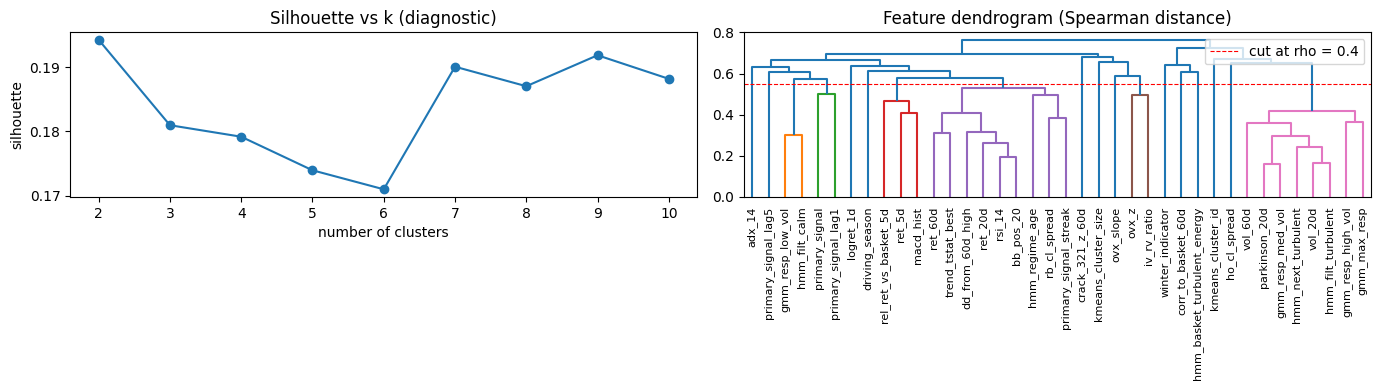

In [13]:
# Cluster the features by their correlation, on the training window only (no leakage).
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
from sklearn.metrics import silhouette_score

# keep only features that actually vary in the training window
cluster_feats = [c for c in X_train.columns if X_train[c].std() > 0]

# Spearman correlation -> Lopez de Prado distance d = sqrt(0.5 (1 - rho))
corr = X_train[cluster_feats].corr(method='spearman')
dist = np.sqrt(0.5 * (1 - corr)).clip(lower=0)
Z = linkage(squareform(dist.values, checks=False), method='average')

# Cut the tree at a correlation threshold, so features only share a cluster if they
# are genuinely correlated. Raise CORR_THRESHOLD for tighter, more numerous groups,
# lower it for fewer, broader ones.
CORR_THRESHOLD = 0.4
dist_cut = np.sqrt(0.5 * (1 - CORR_THRESHOLD))
cluster_id = pd.Series(fcluster(Z, dist_cut, criterion='distance'),
                       index=cluster_feats, name='cluster')
print(f'CORR_THRESHOLD = {CORR_THRESHOLD}  ->  {cluster_id.nunique()} clusters')

# Silhouette curve, kept only as a diagnostic. A flat curve means there is no single best k.
sil = {}
for k in range(2, min(11, len(cluster_feats))):
    labels_k = fcluster(Z, k, criterion='maxclust')
    if len(np.unique(labels_k)) < 2:
        continue
    sil[k] = silhouette_score(dist.values, labels_k, metric='precomputed')

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(list(sil.keys()), list(sil.values()), marker='o')
ax[0].set_xlabel('number of clusters')
ax[0].set_ylabel('silhouette')
ax[0].set_title('Silhouette vs k (diagnostic)')
dendrogram(Z, labels=cluster_feats, ax=ax[1], leaf_rotation=90, color_threshold=dist_cut)
ax[1].axhline(dist_cut, color='red', ls='--', lw=0.8, label=f'cut at rho = {CORR_THRESHOLD}')
ax[1].legend()
ax[1].set_title('Feature dendrogram (Spearman distance)')
plt.tight_layout()
plt.show()

### 7.2 Cluster Composition and Names

We list the features in each cluster and attach a readable name from the dominant theme of its members, for example volatility, momentum, energy spreads or implied vol. The names are only a suggestion, the `cluster_names` dictionary can be edited if a label does not fit. These names carry through to the factor columns and to the cluster-level importance analysis later on.

In [14]:
# Show the members of each cluster and auto-suggest a readable name from the dominant theme.
THEME = {
    'logret_1d': 'returns', 'ret_5d': 'returns', 'ret_20d': 'returns', 'ret_60d': 'returns',
    'vol_20d': 'volatility', 'vol_60d': 'volatility', 'parkinson_20d': 'volatility', 'vol_of_vol_20d': 'volatility',
    'rsi_14': 'oscillators', 'macd_hist': 'oscillators', 'bb_pos_20': 'oscillators',
    'adx_14': 'trend', 'trend_tstat_best': 'trend', 'dd_from_60d_high': 'drawdown',
    'crack_321_z_60d': 'energy_spreads', 'ho_cl_spread': 'energy_spreads', 'rb_cl_spread': 'energy_spreads',
    'rel_ret_vs_basket_5d': 'cross_sectional', 'corr_to_basket_60d': 'cross_sectional',
    'winter_indicator': 'seasonality', 'driving_season': 'seasonality',
    'ovx_z': 'implied_vol', 'iv_rv_ratio': 'implied_vol', 'ovx_slope': 'implied_vol',
    'gmm_resp_low_vol': 'regime', 'gmm_resp_med_vol': 'regime', 'gmm_resp_high_vol': 'regime', 'gmm_max_resp': 'regime',
    'hmm_filt_calm': 'regime', 'hmm_filt_turbulent': 'regime', 'hmm_next_turbulent': 'regime',
    'hmm_regime_age': 'regime', 'hmm_basket_turbulent_energy': 'regime',
    'kmeans_cluster_id': 'regime', 'kmeans_cluster_size': 'regime',
    'primary_signal': 'signal', 'primary_signal_lag1': 'signal', 'primary_signal_lag5': 'signal', 'primary_signal_streak': 'signal',
}

cluster_names, used = {}, {}
for c in sorted(cluster_id.unique()):
    members = list(cluster_id[cluster_id == c].index)
    themes = pd.Series([THEME.get(m, 'other') for m in members]).value_counts()
    name = themes.index[0]
    if len(themes) > 1 and themes.iloc[1] == themes.iloc[0]:
        name = f'{themes.index[0]}_{themes.index[1]}'   # tie, combine the top two themes
    used[name] = used.get(name, 0) + 1
    if used[name] > 1:
        name = f'{name}_{used[name]}'                    # keep the names unique
    cluster_names[c] = name
    print(f'cluster {c:>2}  ->  {name:<22} {members}')

# Edit cluster_names here if any auto-suggested label does not fit.

cluster  1  ->  regime                 ['gmm_resp_low_vol', 'hmm_filt_calm']
cluster  2  ->  signal                 ['primary_signal', 'primary_signal_lag1']
cluster  3  ->  signal_2               ['primary_signal_lag5']
cluster  4  ->  trend                  ['adx_14']
cluster  5  ->  returns_oscillators    ['ret_5d', 'macd_hist', 'rel_ret_vs_basket_5d']
cluster  6  ->  returns_oscillators_2  ['ret_20d', 'ret_60d', 'rsi_14', 'bb_pos_20', 'dd_from_60d_high', 'trend_tstat_best', 'rb_cl_spread', 'hmm_regime_age', 'primary_signal_streak']
cluster  7  ->  seasonality            ['driving_season']
cluster  8  ->  returns                ['logret_1d']
cluster  9  ->  implied_vol            ['ovx_z', 'iv_rv_ratio']
cluster 10  ->  implied_vol_2          ['ovx_slope']
cluster 11  ->  regime_2               ['kmeans_cluster_size']
cluster 12  ->  energy_spreads         ['crack_321_z_60d']
cluster 13  ->  cross_sectional        ['corr_to_basket_60d']
cluster 14  ->  regime_3               ['hmm_b

### 7.3 Within-Cluster PC1

Each cluster is reduced to a single factor, the first principal component taken within that cluster. This keeps the denoising benefit of PCA but ties every factor to one named group, so we can still say which group drives the model. We sign-align each component to its cluster mean so a higher value has a consistent meaning, and we report how much of the cluster variance the first component captures. The scaler and the components are fit on the training window and then applied to the test window.

**Why a RobustScaler:** Everywhere we standardise features in this notebook, before the within-cluster PCA here, and again for the logistic-regression and neural-network inputs in Section 9, we use a `RobustScaler` (centre on the median, scale by the interquartile range) rather than a `StandardScaler`. Natural gas returns are fat-tailed and event-driven, so a few extreme sessions would inflate the standard deviation and squash the rest of the distribution, whereas the median and IQR are barely moved by those outliers. The bulk of the data is therefore scaled consistently and no single shock day dominates the PCA or the model inputs.

In [15]:
# Reduce each cluster to a single factor, the first principal component within that cluster.
# The scaler, the clustering and the sign alignment are all fit on the training window only.
scaler = RobustScaler()
Xtr_s = pd.DataFrame(scaler.fit_transform(X_train[cluster_feats]), index=X_train.index, columns=cluster_feats)
Xte_s = pd.DataFrame(scaler.transform(X_test[cluster_feats]),      index=X_test.index,  columns=cluster_feats)

cluster_pca, evr, train_fac, test_fac = {}, {}, {}, {}
for c in sorted(cluster_id.unique()):
    members = list(cluster_id[cluster_id == c].index)
    p = PCA(n_components=1, random_state=42)
    tr = p.fit_transform(Xtr_s[members]).ravel()
    te = p.transform(Xte_s[members]).ravel()
    if np.corrcoef(tr, Xtr_s[members].mean(axis=1))[0, 1] < 0:   # sign-align to the cluster mean
        tr, te = -tr, -te
    name = cluster_names[c]
    train_fac[name], test_fac[name] = tr, te
    evr[name] = p.explained_variance_ratio_[0]
    cluster_pca[c] = p

train_pca_df = pd.DataFrame(train_fac, index=X_train.index)
test_pca_df  = pd.DataFrame(test_fac,  index=X_test.index)
X_train_pca, X_test_pca = train_pca_df.values, test_pca_df.values
pc_cols = list(train_pca_df.columns)

print('cluster factors:', pc_cols)
print('PC1 variance explained per cluster:', {k: round(v, 2) for k, v in evr.items()})
print(f'reduced from {len(cluster_feats)} features to {len(pc_cols)} cluster factors')
train_pca_df.head()

cluster factors: ['regime', 'signal', 'signal_2', 'trend', 'returns_oscillators', 'returns_oscillators_2', 'seasonality', 'returns', 'implied_vol', 'implied_vol_2', 'regime_2', 'energy_spreads', 'cross_sectional', 'regime_3', 'seasonality_2', 'regime_4', 'energy_spreads_2', 'regime_5']
PC1 variance explained per cluster: {'regime': 0.89, 'signal': 0.75, 'signal_2': 1.0, 'trend': 1.0, 'returns_oscillators': 0.73, 'returns_oscillators_2': 0.56, 'seasonality': 1.0, 'returns': 1.0, 'implied_vol': 0.8, 'implied_vol_2': 1.0, 'regime_2': 1.0, 'energy_spreads': 1.0, 'cross_sectional': 1.0, 'regime_3': 1.0, 'seasonality_2': 1.0, 'regime_4': 0.73, 'energy_spreads_2': 1.0, 'regime_5': 1.0}
reduced from 38 features to 18 cluster factors


,regime,signal,signal_2,trend,returns_oscillators,returns_oscillators_2,seasonality,returns,implied_vol,implied_vol_2,regime_2,energy_spreads,cross_sectional,regime_3,seasonality_2,regime_4,energy_spreads_2,regime_5
date,,,,,,,,,,,,,,,,,,
2020-01-13,0.836237,0.098748,0.067332,-0.029076,1.135879,-1.370641,-0.391521,0.443937,-0.054125,0.210492,0.551953,1.061484,0.772573,0.575557,0.715711,-0.970740,-2.183404,-0.526185
2020-01-14,0.829439,0.098748,0.067332,-0.106289,1.082664,-1.445742,-0.391521,-0.225553,-0.000540,0.195606,0.551953,1.300903,0.793412,0.575452,0.715711,-0.802066,-2.172994,-0.526185
2020-01-15,0.818536,0.098748,0.067332,-0.228928,0.877908,-1.410850,-0.391521,0.072834,-0.008646,-0.004105,0.551953,-0.139561,0.791433,0.575741,0.715711,-0.679295,-2.092832,-0.526185
2020-01-16,0.818026,0.098748,0.067332,-0.246048,0.252712,-1.812488,-0.391521,-0.800446,-0.475652,-0.766684,0.218620,-0.612688,0.822082,0.575117,0.715711,-0.697367,-2.296756,-0.526185
2020-01-17,0.814315,0.098748,0.067332,-0.222537,-0.345924,-1.983314,-0.391521,-0.522690,-0.636974,-0.498895,-0.114713,-0.857445,0.788202,0.575723,0.715711,-0.723028,-2.739610,-0.526185


### 7.4 HMM Regime Filtering

We choose the number of hidden states with a BIC sweep, fitting candidate models with 2 to 5 states and several random seeds and keeping the lowest BIC. We then run the forward algorithm by hand to obtain filtering posteriors on the cluster factors. Filtering uses only past and present data, unlike the smoothing that `predict_proba` would apply, so the regime probabilities that feed the meta-model stay free of look-ahead. We also compute a one-step-ahead forecast by pushing the current filtered state through the transition matrix.

In [16]:
# BIC sweep for the optimal number of HMM states, capped at 5

def hmm_bic(model, X):
    K = model.n_components
    T, d = X.shape
    logL = model.score(X)
    k_params = (K - 1) + K * (K - 1) + K * (2 * d)
    return -2 * logL + k_params * np.log(T), logL

best = {'bic': np.inf, 'hmm': None, 'K': None}
for K in range(2, 6):
    best_for_K = {'bic': np.inf, 'hmm': None}
    for seed in range(10):
        h = GaussianHMM(n_components=K, covariance_type='diag',
                        n_iter=1000, random_state=42 + seed)
        try:
            h.fit(X_train_pca)
            bic, _ = hmm_bic(h, X_train_pca)
            if bic < best_for_K['bic']:
                best_for_K = {'bic': bic, 'hmm': h}
        except Exception:
            continue
    print(f'K={K}: BIC={best_for_K["bic"]:,.1f}')
    if best_for_K['bic'] < best['bic']:
        best = {'bic': best_for_K['bic'], 'hmm': best_for_K['hmm'], 'K': K}

print('Chosen K =', best['K'])

Model is not converging.  Current: -6825.355368792238 is not greater than -6825.278975915295. Delta is -0.07639287694291852
Model is not converging.  Current: -6825.356898852123 is not greater than -6825.351083468599. Delta is -0.005815383523440687
Model is not converging.  Current: -5892.149125625444 is not greater than -5892.149121575148. Delta is -4.050296411151066e-06
Model is not converging.  Current: -5892.149125625424 is not greater than -5892.149121575157. Delta is -4.05026730732061e-06


K=2: BIC=13,049.0
K=3: BIC=10,549.9


Model is not converging.  Current: -3591.100993084646 is not greater than -3590.876136798577. Delta is -0.22485628606864339
Model is not converging.  Current: -3475.483368798934 is not greater than -3475.4000623862325. Delta is -0.08330641270140404
Model is not converging.  Current: -4170.001679741092 is not greater than -4169.192279727323. Delta is -0.8094000137689363
Model is not converging.  Current: -3555.814355445069 is not greater than -3555.813792898077. Delta is -0.0005625469921142212
Model is not converging.  Current: -3636.151199627815 is not greater than -3636.0820927903255. Delta is -0.06910683748947122
Model is not converging.  Current: -2856.600562859118 is not greater than -2856.3785662872074. Delta is -0.22199657191049482
Model is not converging.  Current: -3321.1360583951914 is not greater than -3321.135792514108. Delta is -0.0002658810835782788
Model is not converging.  Current: -2810.772956032352 is not greater than -2810.7369283274707. Delta is -0.03602770488123497


K=4: BIC=7,903.7


Model is not converging.  Current: -3161.319511566973 is not greater than -3161.3189779759223. Delta is -0.0005335910504982166
Model is not converging.  Current: -2924.874544350325 is not greater than -2924.2580724836216. Delta is -0.6164718667032503
Model is not converging.  Current: -3039.116701225272 is not greater than -3039.103926850864. Delta is -0.012774374408309086
Model is not converging.  Current: -2906.2979447667353 is not greater than -2906.255242854438. Delta is -0.04270191229716147


K=5: BIC=6,844.3
Chosen K = 5


In [17]:
# IMPORTANT: predict_proba runs forward-backward (smoothing) which uses future
# data inside the train window. For meta-model features we want filtering only.
# Below: filtering posteriors via the forward algorithm.

def hmm_filter(model, X):
    """Forward-only filtering posterior - no future leakage."""
    T = len(X)
    K = model.n_components
    log_alpha = np.empty((T, K))
    # initial
    log_alpha[0] = np.log(model.startprob_ + 1e-300) + model._compute_log_likelihood(X[:1])[0]
    log_trans = np.log(model.transmat_ + 1e-300)
    log_obs = model._compute_log_likelihood(X)
    for t in range(1, T):
        # log_alpha[t,k] = logsumexp_j(log_alpha[t-1,j] + log_trans[j,k]) + log_obs[t,k]
        m = log_alpha[t-1, :, None] + log_trans   # (K, K)
        log_alpha[t] = log_obs[t] + (m.max(axis=0) +
                                     np.log(np.exp(m - m.max(axis=0)).sum(axis=0)))
    # normalise to get posteriors
    log_alpha -= log_alpha.max(axis=1, keepdims=True)
    a = np.exp(log_alpha)
    return a / a.sum(axis=1, keepdims=True)

train_post = hmm_filter(best['hmm'], X_train_pca)
test_post  = hmm_filter(best['hmm'], X_test_pca)

for i in range(best['K']):
    train_pca_df[f'hmm_filt_{i}'] = train_post[:, i]
    test_pca_df[f'hmm_filt_{i}']  = test_post[:, i]

train_pca_df.head()

,regime,signal,signal_2,trend,returns_oscillators,returns_oscillators_2,seasonality,returns,implied_vol,implied_vol_2,...,regime_3,seasonality_2,regime_4,energy_spreads_2,regime_5,hmm_filt_0,hmm_filt_1,hmm_filt_2,hmm_filt_3,hmm_filt_4
date,,,,,,,,,,,,,,,,,,,,,
2020-01-13,0.836237,0.098748,0.067332,-0.029076,1.135879,-1.370641,-0.391521,0.443937,-0.054125,0.210492,...,0.575557,0.715711,-0.970740,-2.183404,-0.526185,6.015573e-41,1.000000,0.0,0.0,0.0
2020-01-14,0.829439,0.098748,0.067332,-0.106289,1.082664,-1.445742,-0.391521,-0.225553,-0.000540,0.195606,...,0.575452,0.715711,-0.802066,-2.172994,-0.526185,2.014535e-05,0.999980,0.0,0.0,0.0
2020-01-15,0.818536,0.098748,0.067332,-0.228928,0.877908,-1.410850,-0.391521,0.072834,-0.008646,-0.004105,...,0.575741,0.715711,-0.679295,-2.092832,-0.526185,1.272957e-04,0.999873,0.0,0.0,0.0
2020-01-16,0.818026,0.098748,0.067332,-0.246048,0.252712,-1.812488,-0.391521,-0.800446,-0.475652,-0.766684,...,0.575117,0.715711,-0.697367,-2.296756,-0.526185,8.701791e-06,0.999991,0.0,0.0,0.0
2020-01-17,0.814315,0.098748,0.067332,-0.222537,-0.345924,-1.983314,-0.391521,-0.522690,-0.636974,-0.498895,...,0.575723,0.715711,-0.723028,-2.739610,-0.526185,9.230874e-08,1.000000,0.0,0.0,0.0


## 8. Triple-Barrier Meta-Labels

We label each primary signal with the triple-barrier method. A trade counts as a win if the profit-taking barrier is reached before the stop-loss or the time limit. These labels become the target the meta-model learns to predict for natural gas.

**Why these barrier choices make sense for natural gas**

**Volatility scaling with EWM span 20:** The daily vol estimate uses a 20-day exponentially weighted standard deviation of log returns, and the exponential weighting is deliberate. The natural gas market is event-driven. A surprise EIA storage print or a shift in the weather forecast can double realised vol overnight, and natural gas is one of the most volatile of all the energy futures. A simple rolling standard deviation treats every observation equally, so a spike three weeks ago carries the same weight as yesterday, whereas the EWM decays older observations so the vol estimate at trade entry reflects the current regime rather than a stale average. The 20-day span sits at roughly one trading month, long enough to avoid noise from a single session but short enough to adapt within a few weeks when the regime genuinely shifts.

**Symmetric barriers at pt_sl = [1.5, 1.5]:** The symmetry is intentional, it means the label is not pre-tilted toward wins or losses by construction. If the profit-take were wider than the stop-loss, the win rate would be inflated and the meta-label distribution would be harder to interpret. The 1.5 multiplier reflects natural gas's return distribution, which has fat tails and persistent ranges. A multiplier of 1.0 would set barriers just one standard deviation from entry, which gets hit constantly by noise rather than genuine directional moves, while a multiplier of 2.0 or higher would push too many trades to the time barrier and degrade label quality.

**Maximum hold of 20 days:** Twenty trading days is one calendar month, which is the right horizon for a trend-following signal on an energy instrument. Signals based on regime state, energy spreads, and trend-scanning t-statistics pick up moves that play out over days to weeks, not hours, so a 5-day hold is too short for them to resolve. A 60-day hold would introduce roll risk and force the model to hold through multiple EIA storage reports, weather-driven demand swings, and seasonal transitions, all of which can reverse the original signal rationale. The EIA weekly natural gas storage report lands every Thursday, so 20 trading days covers roughly four report cycles. A signal that has not resolved after four of those cycles has probably lost its original context. A shorter hold would also push more labels to the time barrier, producing ambiguous outcomes for trades that were neither right nor wrong, so 20 days gives a reasonable fraction of clean barrier touches, which is what a well-calibrated meta-label dataset needs.

In [18]:
def get_daily_vol(close, span=20):
    log_ret = np.log(close).diff()
    return log_ret.ewm(span=span).std()

def triple_barrier_meta_labels(close, signals, pt_sl, max_hold):
    vol = get_daily_vol(close)
    out = []
    for t0, side in signals.items():
        if pd.isna(side) or side == 0:
            continue
        if t0 not in close.index or t0 not in vol.index:
            continue
        sigma = vol.loc[t0]
        if pd.isna(sigma) or sigma <= 0:
            continue
        idx = close.index.searchsorted(t0)
        # Decoupled edge fix: tail signals with no full forward window have no
        # triple-barrier label (the path would be truncated, biasing the label
        # toward time-barrier outcomes). They still receive a prediction in the
        # export cell: predictions need only features. The label needs the path.
        # Tail counts are verified per instrument in sanity_checks.ipynb.
        if idx + max_hold >= len(close.index):
            continue
        pt =  pt_sl[0] * sigma
        sl = -pt_sl[1] * sigma
        t1 = close.index[idx + max_hold]
        entry = close.loc[t0]
        future = close.loc[t0:t1].iloc[1:]
        if future.empty:
            continue
        ret = (future / entry - 1) * side
        hit_pt = ret[ret >= pt].index.min()
        hit_sl = ret[ret <= sl].index.min()
        cand = {k: v for k, v in {'pt': hit_pt, 'sl': hit_sl, 't1': t1}.items()
                if pd.notna(v)}
        first = min(cand, key=cand.get)
        out.append({
            'entry': t0, 'exit': cand[first],
            'sigma_at_entry': sigma, 'primary_signal': side,
            'first_touch': first,
            'meta_label': 1 if first == 'pt' else 0,
        })
    return pd.DataFrame(out).set_index('entry')

# Use raw close from the OHLCV file (the parquet drops it on save)
# Use the ng1s close, not cl1s, so the labels are priced on the correct instrument
ohlcv = pd.read_csv('../data/src/ohlcv_data.csv')
ohlcv['date'] = pd.to_datetime(ohlcv['date'])
ng_close = (
    ohlcv[ohlcv['instrument'] == 'ng1s']
    .set_index('date')['close']
    .sort_index()
)

natural_gas_signals = natural_gas['primary_signal'].dropna()
natural_gas_labels = triple_barrier_meta_labels(ng_close, natural_gas_signals, pt_sl=[1.5, 1.5], max_hold=20)
print('labels:', len(natural_gas_labels), 'win rate:', natural_gas_labels['meta_label'].mean().round(3))
natural_gas_labels.head()


labels: 115 win rate: 0.496


,exit,sigma_at_entry,primary_signal,first_touch,meta_label
entry,,,,,
2020-05-05,2020-05-06,0.046497,-1.0,pt,1
2020-05-06,2020-05-12,0.054266,-1.0,pt,1
2020-05-07,2020-05-12,0.052267,-1.0,pt,1
2020-05-08,2020-05-13,0.050937,-1.0,pt,1
2020-05-11,2020-05-13,0.048491,-1.0,pt,1


**Decoupling prediction from labelling at the data edge.** The labeller above skips any signal where `idx + max_hold >= len(close.index)`, i.e. the last ~`max_hold` (20) signalled days of the available data. The triple-barrier rule needs a full forward window to be unbiased. A truncated path silently biases the label toward time-barrier (`0`) outcomes. Skipping these signals keeps training and the Section 11.1 evaluation honest.

Predictions are decoupled from this: the model scores rows whenever the features exist, regardless of whether the label is computable. The export cell at the end of this notebook builds its prediction matrix on **all signalled days in the deliverable window**, not just labelled ones, so the deliverable CSV has a row with a real probability for every signal, including the unlabellable tail.

This matters most on the hidden H2 2022 rerun: the labeller is data-end-aware (so the late-December tail does not pollute selection or evaluation), but predictions still cover that tail. The `sanity_checks.ipynb` notebook reports the per-instrument count of dropped tail labels and predicted-but-unlabelled days.

In [19]:
# Align X with the labels, same pattern as the other notebooks
y_train = natural_gas_labels.loc[natural_gas_labels.index <  SIGNAL_START, 'meta_label']
y_test  = natural_gas_labels.loc[natural_gas_labels.index >= SIGNAL_START, 'meta_label']

X_train_natural_gas = train_pca_df.reindex(y_train.index).dropna()
X_test_natural_gas  = test_pca_df.reindex(y_test.index).dropna()
y_train = y_train.loc[X_train_natural_gas.index]
y_test  = y_test.loc[X_test_natural_gas.index]

print(X_train_natural_gas.shape, y_train.shape)
print(X_test_natural_gas.shape,  y_test.shape)

(28, 23) (28,)
(87, 23) (87,)


## 9. Models

In this section we build the meta-models with logistic regression, random forest, XGBoost, and three neural networks. We compare them with walk-forward cross-validation, which respects the time order of the data and scores each candidate by AUC across the expanding folds, then retrain the best of each on the full training set and evaluate once on the held-out test set.

In [20]:
N_SPLITS = 5

def walk_forward_cv_auc(model, X, y, n_splits=N_SPLITS):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    fold_aucs = []
    for train_idx, test_idx in tscv.split(X.values):
        X_tr, X_te = X.values[train_idx], X.values[test_idx]
        y_tr, y_te = y.values[train_idx], y.values[test_idx]
        if len(np.unique(y_tr)) < 2:  # guard on the train split, prevents a fit crash
            continue
        if len(np.unique(y_te)) < 2:  # guard on the validation split, prevents an AUC crash
            continue
        model.fit(X_tr, y_tr)
        proba = model.predict_proba(X_te)[:, 1]
        fold_aucs.append(roc_auc_score(y_te, proba))
    if len(fold_aucs) == 0:           # safe return when all folds are skipped
        return {'fold_aucs': [], 'mean_auc': np.nan, 'std_auc': np.nan}
    return {'fold_aucs': fold_aucs, 'mean_auc': np.mean(fold_aucs), 'std_auc': np.std(fold_aucs)}


### 9.1 Logistic Regression

A linear baseline. With only a few hundred labelled training observations, regularisation is the parameter that matters most, so the grid sweeps the inverse regularisation strength `C` across both L2 and L1 penalties and adds balanced class weights for the imbalanced meta-label distribution. L2 keeps every coefficient small, while L1 can zero out the least informative of the per-cluster PC1 factors, which on a small sample often generalises better because it commits to fewer signals rather than spreading weight across all of them. We avoid effectively unregularised settings, since on this sample size they overfit the CV folds and any win is likely an artefact of a favourable split.

In [21]:
# Logistic regression parameter grid

lr_param_grid = [
    {'C': 0.01,  'penalty': 'l2', 'class_weight': None,       'solver': 'lbfgs',     'max_iter': 1000},
    {'C': 0.1,   'penalty': 'l2', 'class_weight': None,       'solver': 'lbfgs',     'max_iter': 1000},
    {'C': 1.0,   'penalty': 'l2', 'class_weight': None,       'solver': 'lbfgs',     'max_iter': 1000},
    {'C': 10.0,  'penalty': 'l2', 'class_weight': None,       'solver': 'lbfgs',     'max_iter': 1000},
    {'C': 0.1,   'penalty': 'l1', 'class_weight': None,       'solver': 'liblinear', 'max_iter': 1000},
    {'C': 1.0,   'penalty': 'l1', 'class_weight': None,       'solver': 'liblinear', 'max_iter': 1000},
    {'C': 0.1,   'penalty': 'l2', 'class_weight': 'balanced', 'solver': 'lbfgs',     'max_iter': 1000},
    {'C': 1.0,   'penalty': 'l2', 'class_weight': 'balanced', 'solver': 'lbfgs',     'max_iter': 1000},
]

lr_results = []
for params in lr_param_grid:
    pipe = Pipeline([('scaler', RobustScaler()), ('clf', LogisticRegression(**params))])
    cv = walk_forward_cv_auc(pipe, X_train_natural_gas, y_train)
    lr_results.append({**params, **cv})

lr_df = pd.DataFrame(lr_results).sort_values('mean_auc', ascending=False)
print(lr_df[['C', 'penalty', 'class_weight', 'mean_auc', 'std_auc']].to_string(index=False))
best_lr_params = lr_df.iloc[0][['C', 'penalty', 'class_weight', 'solver', 'max_iter']].to_dict()

    C penalty class_weight  mean_auc  std_auc
 1.00      l1         None  0.888889 0.157135
 0.01      l2         None  0.666667 0.471405
 0.10      l2         None  0.666667 0.471405
 1.00      l2         None  0.666667 0.471405
10.00      l2         None  0.666667 0.471405
 0.10      l1         None  0.666667 0.272166
 0.10      l2     balanced  0.666667 0.471405
 1.00      l2     balanced  0.666667 0.471405


### 9.2 Random Forest

A bagged tree model that captures non-linear interactions between the regime features and signal quality. On a few hundred observations the leaf size is the primary regularisation lever, since a leaf of only a handful of samples lets the tree learn splits tied to specific dates rather than anything that looks like a regime. The grid therefore tunes the tree depth, the minimum samples per leaf, the number of features considered at each split, and the class weighting, keeping the depth shallow enough to avoid spurious interactions while still allowing the few splits it takes to express a condition like a bullish signal in a high-OVX, turbulent regime.

In [22]:
# -----------------------------------------------------------------------
# Random Forest
# max_depth      : shallow (3-5) = less overfit. None = fully grown.
# min_samples_leaf: higher = smoother, more regularised splits.
# max_features   : features per split. lower = more diverse trees.
# -----------------------------------------------------------------------
rf_param_grid = [
    {'n_estimators': 100, 'max_depth': 3,    'min_samples_leaf': 5,  'max_features': 'sqrt', 'class_weight': None},
    {'n_estimators': 100, 'max_depth': 5,    'min_samples_leaf': 5,  'max_features': 'sqrt', 'class_weight': None},
    {'n_estimators': 100, 'max_depth': 8,    'min_samples_leaf': 5,  'max_features': 'sqrt', 'class_weight': None},
    {'n_estimators': 200, 'max_depth': 5,    'min_samples_leaf': 10, 'max_features': 'sqrt', 'class_weight': None},
    {'n_estimators': 200, 'max_depth': 8,    'min_samples_leaf': 10, 'max_features': 'sqrt', 'class_weight': None},
    {'n_estimators': 200, 'max_depth': 4,    'min_samples_leaf': 20, 'max_features': 'sqrt', 'class_weight': None},
    {'n_estimators': 200, 'max_depth': 5,    'min_samples_leaf': 5,  'max_features': 0.5,    'class_weight': None},
    {'n_estimators': 200, 'max_depth': 5,    'min_samples_leaf': 10, 'max_features': 'sqrt', 'class_weight': 'balanced'},
]

rf_results = []
for params in rf_param_grid:
    model = RandomForestClassifier(**params, random_state=42, n_jobs=-1)
    cv = walk_forward_cv_auc(model, X_train_natural_gas, y_train)  # natural gas training matrix
    rf_results.append({**params, **cv})

rf_df = pd.DataFrame(rf_results).sort_values('mean_auc', ascending=False)
print(rf_df[['n_estimators', 'max_depth', 'min_samples_leaf', 'mean_auc', 'std_auc']].to_string(index=False))
best_rf_params = rf_df.iloc[0][['n_estimators', 'max_depth', 'min_samples_leaf', 'max_features', 'class_weight']].to_dict()


 n_estimators  max_depth  min_samples_leaf  mean_auc  std_auc
          100          3                 5  0.555556  0.41574
          100          5                 5  0.555556  0.41574
          100          8                 5  0.555556  0.41574
          200          5                 5  0.555556  0.41574
          200          5                10  0.500000  0.00000
          200          8                10  0.500000  0.00000
          200          4                20  0.500000  0.00000
          200          5                10  0.500000  0.00000


### 9.3 XGBoost

A gradient-boosted tree model. We tune the learning rate, the depth, the subsample and column-sample fractions, and we use `scale_pos_weight` to handle the class imbalance. The most important regularisation lever on a small dataset is `min_child_weight`, the minimum sum of instance weights required in a leaf, which is XGBoost's equivalent of a minimum leaf size. At its default of 1 a leaf can represent a single observation, which on a few hundred samples is memorisation rather than learning, so we keep the trees shallow and the leaves well populated so that each split is supported by enough data to generalise across different market conditions.

In [23]:
# XGBoost parameter grid, we try several settings and keep the best
# -----------------------------------------------------------------------
# XGBoost
# learning_rate  : smaller = more rounds needed but better generalisation.
# max_depth      : 3-5 is usually optimal for financial data.
# subsample      : fraction of rows per tree. <1.0 reduces overfit.
# colsample_bytree: fraction of features per tree. same idea.
# scale_pos_weight: n_neg/n_pos. compensates for class imbalance.
# min_child_weight: minimum summed instance weight per leaf. Holding it above 1
#                  stops splits down to single-observation leaves, the key small-sample
#                  regularisation lever discussed in 9.3.
# -----------------------------------------------------------------------
n_pos = int(y_train.sum())
n_neg = len(y_train) - n_pos
spw = n_neg / n_pos
print(f'scale_pos_weight = {spw:.2f}  (n_neg={n_neg}, n_pos={n_pos})')

xgb_param_grid = [
    {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 3, 'subsample': 0.8, 'colsample_bytree': 0.8, 'scale_pos_weight': 1.0},
    {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 3, 'subsample': 0.8, 'colsample_bytree': 0.8, 'scale_pos_weight': 1.0},
    {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 5, 'subsample': 0.8, 'colsample_bytree': 0.8, 'scale_pos_weight': 1.0},
    {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 5, 'subsample': 0.8, 'colsample_bytree': 0.8, 'scale_pos_weight': 1.0},
    {'n_estimators': 100, 'learning_rate': 0.1,  'max_depth': 3, 'min_child_weight': 3, 'subsample': 0.8, 'colsample_bytree': 0.8, 'scale_pos_weight': 1.0},
    {'n_estimators': 100, 'learning_rate': 0.1,  'max_depth': 5, 'min_child_weight': 5, 'subsample': 0.7, 'colsample_bytree': 0.7, 'scale_pos_weight': 1.0},
    {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 3, 'subsample': 0.8, 'colsample_bytree': 0.8, 'scale_pos_weight': spw},
    {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 5, 'subsample': 0.8, 'colsample_bytree': 0.8, 'scale_pos_weight': spw},
]

xgb_results = []
for params in xgb_param_grid:
    model = xgb.XGBClassifier(**params, eval_metric='logloss', random_state=42, verbosity=0)
    cv = walk_forward_cv_auc(model, X_train_natural_gas, y_train)
    xgb_results.append({**params, **cv})

xgb_df = pd.DataFrame(xgb_results).sort_values('mean_auc', ascending=False)
print(xgb_df[['n_estimators', 'learning_rate', 'max_depth', 'min_child_weight', 'subsample', 'scale_pos_weight', 'mean_auc', 'std_auc']].to_string(index=False))
best_xgb_params = xgb_df.iloc[0][['n_estimators', 'learning_rate', 'max_depth', 'min_child_weight', 'subsample', 'colsample_bytree', 'scale_pos_weight']].to_dict()

scale_pos_weight = 0.40  (n_neg=8, n_pos=20)
 n_estimators  learning_rate  max_depth  min_child_weight  subsample  scale_pos_weight  mean_auc  std_auc
          100           0.05          3                 3        0.8               1.0       0.5      0.0
          200           0.05          3                 3        0.8               1.0       0.5      0.0
          100           0.05          5                 5        0.8               1.0       0.5      0.0
          200           0.05          5                 5        0.8               1.0       0.5      0.0
          100           0.10          3                 3        0.8               1.0       0.5      0.0
          100           0.10          5                 5        0.7               1.0       0.5      0.0
          200           0.05          3                 3        0.8               0.4       0.5      0.0
          200           0.05          5                 5        0.8               0.4       0.5      0.0


### 9.4 Retrain Best Models and Evaluate on Test

We refit the best logistic regression, random forest, and XGBoost on the full training set and score each once on the held-out test set, reporting the test AUC per model. A fuller threshold-by-threshold breakdown for every model follows in the evaluation section.

In [24]:
# -----------------------------------------------------------------------
# Summary: retrain best of each on full X_train, evaluate once on X_test
# -----------------------------------------------------------------------
best_lr  = Pipeline([('scaler', RobustScaler()), ('clf', LogisticRegression(**best_lr_params))])
best_rf  = RandomForestClassifier(**best_rf_params, random_state=42, n_jobs=-1)
best_xgb = xgb.XGBClassifier(**best_xgb_params, eval_metric='logloss', random_state=42, verbosity=0)

for name, model in [('LR', best_lr), ('RF', best_rf), ('XGB', best_xgb)]:
    model.fit(X_train_natural_gas, y_train)
    proba = model.predict_proba(X_test_natural_gas)[:, 1]
    print(f'{name}  test AUC: {roc_auc_score(y_test, proba):.4f}')

LR  test AUC: 0.6270
RF  test AUC: 0.6400
XGB  test AUC: 0.5000


### 9.5 Neural Network Setup

The neural networks need their own feature scaling and their own walk-forward cross-validation helper, which trains a freshly compiled Keras model on each fold and scores it by AUC. Building this once keeps the three network sections below consistent with the walk-forward discipline used for the classical models.

In [25]:
scaler_nn = RobustScaler()
X_tr_sc = scaler_nn.fit_transform(X_train_natural_gas.values).astype(np.float32)
X_te_sc = scaler_nn.transform(X_test_natural_gas.values).astype(np.float32)
input_dim = X_tr_sc.shape[1]

y_tr = y_train.values.astype(np.float32)
y_te = y_test.values.astype(np.float32)

# pos_weight for class imbalance: same logic as XGB scale_pos_weight
n_pos = y_tr.sum()
n_neg = len(y_tr) - n_pos
pos_weight = n_neg / max(n_pos, 1)
print(f'input_dim={input_dim}, pos_weight={pos_weight:.2f}')


input_dim=23, pos_weight=0.40


In [26]:
# Neural network models

# -----------------------------------------------------------------------
# Walk-forward CV helper for Keras models
# model_fn: a callable that returns a freshly compiled Keras model
# X, y: numpy arrays already scaled
# -----------------------------------------------------------------------
def walk_forward_cv_keras(model_fn, X, y, n_splits=N_SPLITS,
                           epochs=80, batch_size=32, patience=10):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    fold_aucs = []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
        X_f, X_v = X[train_idx], X[val_idx]
        y_f, y_v = y[train_idx], y[val_idx]

        if len(np.unique(y_f)) < 2:  # FIXED: guard on train split
            continue
        if len(np.unique(y_v)) < 2:  # guard on val split
            continue

        model = model_fn()

        early_stop = keras.callbacks.EarlyStopping(
            monitor='val_auc',
            patience=patience,
            mode='max',
            restore_best_weights=True,
        )

        model.fit(
            X_f, y_f,
            validation_data=(X_v, y_v),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=[early_stop],
            verbose=0,
            class_weight={0: pos_weight, 1: 1.0},
        )

        proba = model.predict(X_v, verbose=0).flatten()
        fold_aucs.append(roc_auc_score(y_v, proba))

    if len(fold_aucs) == 0:  # safe return when all folds are skipped
        return {'fold_aucs': [], 'mean_auc': np.nan, 'std_auc': np.nan}
    return {
        'fold_aucs': fold_aucs,
        'mean_auc':  float(np.mean(fold_aucs)),
        'std_auc':   float(np.std(fold_aucs)),
    }


### 9.6 MLP

A feedforward network with two hidden layers, batch normalisation, dropout, and a sigmoid output. The tunable parameters are the layer width, the dropout rate, and the learning rate. With only a few hundred training samples, dropout is the primary regularisation lever, so wider networks are paired with more aggressive dropout to stay generalised. We keep the depth fixed at two layers, since more depth needs more data to train reliably and would add noise to the search rather than useful signal.

In [27]:
# -----------------------------------------------------------------------
# Model 1: Feedforward Network (MLP)
#
# Params tuned:
#   hidden_dim : width of each hidden layer
#   dropout    : fraction of neurons dropped during training
#   lr         : Adam learning rate
# -----------------------------------------------------------------------
def make_mlp(hidden_dim=64, dropout=0.3, lr=1e-3):
    keras.utils.set_random_seed(42)  # deterministic weight init, independent of run order
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(hidden_dim, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(dropout),
        layers.Dense(hidden_dim // 2, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(dropout),
        layers.Dense(1, activation='sigmoid'),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(lr),
        loss='binary_crossentropy',
        metrics=[keras.metrics.AUC(name='auc')],
    )
    return model


mlp_param_grid = [
    {'hidden_dim': 32,  'dropout': 0.2, 'lr': 1e-3},
    {'hidden_dim': 64,  'dropout': 0.2, 'lr': 1e-3},
    {'hidden_dim': 64,  'dropout': 0.3, 'lr': 1e-3},
    {'hidden_dim': 128, 'dropout': 0.3, 'lr': 1e-3},
    {'hidden_dim': 64,  'dropout': 0.4, 'lr': 5e-4},
    {'hidden_dim': 128, 'dropout': 0.4, 'lr': 5e-4},
]

mlp_results = []
for params in mlp_param_grid:
    fn = lambda p=params: make_mlp(**p)
    cv = walk_forward_cv_keras(fn, X_tr_sc, y_tr)
    mlp_results.append({**params, **cv})
    print(f"hidden={params['hidden_dim']} dropout={params['dropout']} lr={params['lr']}  "
          f"mean_auc={cv['mean_auc']:.4f} std={cv['std_auc']:.4f}")
mlp_df = pd.DataFrame(mlp_results).sort_values('mean_auc', ascending=False)
best_mlp_params = {
    'hidden_dim': int(mlp_df.iloc[0]['hidden_dim']),
    'dropout':    float(mlp_df.iloc[0]['dropout']),
    'lr':         float(mlp_df.iloc[0]['lr']),
}
print('\nBest MLP:', best_mlp_params)

2026-06-03 19:44:09.456971: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}
2026-06-03 19:44:09.457560: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

hidden=32 dropout=0.2 lr=0.001  mean_auc=0.5556 std=0.4157


2026-06-03 19:44:20.075759: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-06-03 19:44:20.076074: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

hidden=64 dropout=0.2 lr=0.001  mean_auc=0.6667 std=0.4714


2026-06-03 19:44:26.027223: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-06-03 19:44:26.027652: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

hidden=64 dropout=0.3 lr=0.001  mean_auc=0.5556 std=0.4157


2026-06-03 19:44:31.035867: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2026-06-03 19:44:31.036152: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

hidden=128 dropout=0.3 lr=0.001  mean_auc=0.6667 std=0.4714
hidden=64 dropout=0.4 lr=0.0005  mean_auc=0.1111 std=0.1571


2026-06-03 19:44:36.620463: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-06-03 19:44:36.620754: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

hidden=128 dropout=0.4 lr=0.0005  mean_auc=0.5556 std=0.4157

Best MLP: {'hidden_dim': 64, 'dropout': 0.2, 'lr': 0.001}


### 9.7 Variable Selection Network (VSN)

The VSN learns a softmax weight over the input features at each forward pass, so unlike the MLP, which treats every PC equally, it can suppress features that are not useful in the current regime and up-weight the ones that are. That dynamic selection is genuinely useful for natural gas meta-labelling, where feature relevance shifts across seasons and macro regimes, and the learned weights are interpretable as a bonus. The extra attention layer adds capacity, which makes overfitting more likely on a small sample, so the dropout floor is raised relative to the MLP and the wider configurations use a slower learning rate to give the attention weights time to settle rather than collapsing to uniform values early in training.

In [28]:
# -----------------------------------------------------------------------
# Model 2: Variable Selection Network (VSN)
#
# Learns a soft attention weight per feature so the network suppresses
# irrelevant features dynamically. Useful when you have a small set of cluster factors
# from different tiers where relevance shifts across regimes.
#
# How it works:
#   - A dense layer produces one weight per feature, softmaxed to sum to 1
#   - Each feature is individually transformed by its own small dense layer
#   - The weighted sum of transformed features feeds the classifier
# -----------------------------------------------------------------------
def make_vsn(hidden_dim=64, dropout=0.3, lr=1e-3):
    keras.utils.set_random_seed(42)  # deterministic weight init, independent of run order
    inputs = keras.Input(shape=(input_dim,))

    # Feature selection weights: one scalar per input feature
    selection_weights = layers.Dense(input_dim, activation='softmax',
                                     name='feature_weights')(inputs)

    # Per-feature transform: expand each scalar feature to hidden_dim
    # Then weight and sum across features
    expanded = layers.Reshape((input_dim, 1))(inputs)
    transformed = layers.Conv1D(
        filters=hidden_dim, kernel_size=1,
        activation='relu', name='feature_transform'
    )(expanded)                                          # (batch, input_dim, hidden_dim)

    # Apply selection weights: broadcast weights over hidden_dim
    weights_expanded = layers.Reshape((input_dim, 1))(selection_weights)
    weighted = layers.Multiply()([transformed, weights_expanded])
    combined = layers.Lambda(lambda x: tf.reduce_sum(x, axis=1))(weighted)  # (batch, hidden_dim)

    # Classifier head
    x = layers.BatchNormalization()(combined)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(hidden_dim // 2, activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(lr),
        loss='binary_crossentropy',
        metrics=[keras.metrics.AUC(name='auc')],
    )
    return model


vsn_param_grid = [
    {'hidden_dim': 32,  'dropout': 0.2, 'lr': 1e-3},
    {'hidden_dim': 64,  'dropout': 0.2, 'lr': 1e-3},
    {'hidden_dim': 64,  'dropout': 0.3, 'lr': 1e-3},
    {'hidden_dim': 128, 'dropout': 0.3, 'lr': 5e-4},
    {'hidden_dim': 64,  'dropout': 0.4, 'lr': 5e-4},
]

vsn_results = []
for params in vsn_param_grid:
    fn = lambda p=params: make_vsn(**p)
    cv = walk_forward_cv_keras(fn, X_tr_sc, y_tr)
    vsn_results.append({**params, **cv})
    print(f"hidden={params['hidden_dim']} dropout={params['dropout']} lr={params['lr']}  "
          f"mean_auc={cv['mean_auc']:.4f} std={cv['std_auc']:.4f}")

vsn_df = pd.DataFrame(vsn_results).sort_values('mean_auc', ascending=False)
best_vsn_params = {
    'hidden_dim': int(vsn_df.iloc[0]['hidden_dim']),
    'dropout':    float(vsn_df.iloc[0]['dropout']),
    'lr':         float(vsn_df.iloc[0]['lr']),
}
print('\nBest VSN:', best_vsn_params)

2026-06-03 19:44:42.129952: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2026-06-03 19:44:42.130247: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

hidden=32 dropout=0.2 lr=0.001  mean_auc=0.7778 std=0.3143


2026-06-03 19:44:47.875022: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-06-03 19:44:47.875351: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

hidden=64 dropout=0.2 lr=0.001  mean_auc=0.7778 std=0.3143


2026-06-03 19:44:53.537260: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2026-06-03 19:44:53.537591: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

hidden=64 dropout=0.3 lr=0.001  mean_auc=0.7778 std=0.3143


2026-06-03 19:44:59.820956: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-06-03 19:44:59.821315: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

hidden=128 dropout=0.3 lr=0.0005  mean_auc=0.6667 std=0.4714


2026-06-03 19:45:06.138662: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2026-06-03 19:45:06.139752: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

hidden=64 dropout=0.4 lr=0.0005  mean_auc=0.7778 std=0.3143

Best VSN: {'hidden_dim': 32, 'dropout': 0.2, 'lr': 0.001}


### 9.8 LSTM

The LSTM looks at a sequence of the last few days before each trade entry, so it can pick up the temporal pattern leading into the trade rather than a single snapshot. The main tension is between the sequence length, where a longer window gives more context but leaves fewer usable training sequences, and the model capacity, where deeper recurrence risks overfitting. We tune the sequence length, the hidden size, the number of layers, and the dropout, keeping short windows shallow since one or two layers are enough for the temporal dependencies in a short window, and we treat the longest lookback with caution because a high sequence-to-sample ratio is hard to generalise from on a few hundred observations.

In [29]:
# -----------------------------------------------------------------------
# Model 3: LSTM
#
# Builds a sequence of the last seq_len days before each trade entry.
# The LSTM sees the temporal pattern leading into the trade, not just
# the point-in-time snapshot.
#
# Params tuned:
#   seq_len    : how many past days to look back
#   hidden_dim : LSTM hidden state size
#   num_layers : stacked LSTM depth
#   dropout    : applied between layers and before output head
# -----------------------------------------------------------------------
def build_sequences(X_df, y_series, seq_len):
    """
    For each label date, extract seq_len rows ending strictly before
    that date. Returns X_seq (N, seq_len, features) and y_arr (N,).
    """
    X_arr = X_df.values.astype(np.float32)
    dates = X_df.index
    X_seqs, y_out, valid_dates = [], [], []

    for entry_date, label in y_series.items():
        if entry_date not in dates:
            continue
        pos = dates.get_loc(entry_date)
        if pos < seq_len:
            continue
        X_seqs.append(X_arr[pos - seq_len : pos])
        y_out.append(label)
        valid_dates.append(entry_date)

    return (np.array(X_seqs, dtype=np.float32),
            np.array(y_out, dtype=np.float32),
            valid_dates)


def make_lstm(seq_len, hidden_dim=64, num_layers=2, dropout=0.3, lr=1e-3):
    keras.utils.set_random_seed(42)  # deterministic weight init, independent of run order
    model = keras.Sequential()
    model.add(layers.Input(shape=(seq_len, input_dim)))
    for i in range(num_layers):
        return_seq = (i < num_layers - 1)  # all layers except the last return sequences
        model.add(layers.LSTM(hidden_dim, return_sequences=return_seq, dropout=dropout))
    model.add(layers.Dropout(dropout))
    model.add(layers.Dense(hidden_dim // 2, activation='relu'))
    model.add(layers.Dense(1, activation='sigmoid'))
    model.compile(
        optimizer=keras.optimizers.Adam(lr),
        loss='binary_crossentropy',
        metrics=[keras.metrics.AUC(name='auc')],
    )
    return model


# Build the full scaled feature matrix for sequence extraction
# build the scaled matrix from the natural gas arrays
train_cutoff = X_train_natural_gas.index.max()
full_X_sc = pd.DataFrame(
    np.vstack([
        scaler_nn.transform(X_train_natural_gas.values),
        scaler_nn.transform(X_test_natural_gas.values),
    ]),
    index=pd.concat([X_train_natural_gas, X_test_natural_gas]).index,
    columns=X_train_natural_gas.columns,
).astype(np.float32)

lstm_param_grid = [
    {'seq_len': 10, 'hidden_dim': 32, 'num_layers': 1, 'dropout': 0.2, 'lr': 1e-3},
    {'seq_len': 10, 'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.3, 'lr': 1e-3},
    {'seq_len': 20, 'hidden_dim': 32, 'num_layers': 1, 'dropout': 0.2, 'lr': 1e-3},
    {'seq_len': 20, 'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.3, 'lr': 1e-3},
    {'seq_len': 20, 'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.4, 'lr': 5e-4},
    {'seq_len': 60, 'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.3, 'lr': 5e-4},
]

lstm_results = []
for params in lstm_param_grid:
    seq_len = params['seq_len']
    X_seq, y_seq, seq_dates = build_sequences(
        full_X_sc.loc[:train_cutoff], y_train, seq_len
    )
    if len(X_seq) == 0:
        continue

    tscv_seq = TimeSeriesSplit(n_splits=N_SPLITS)
    fold_aucs = []
    for train_idx, val_idx in tscv_seq.split(X_seq):
        X_f, X_v = X_seq[train_idx], X_seq[val_idx]
        y_f, y_v = y_seq[train_idx], y_seq[val_idx]
        if len(np.unique(y_v)) < 2:
            continue

        model = make_lstm(**params)
        early_stop = keras.callbacks.EarlyStopping(
            monitor='val_auc', patience=10, mode='max', restore_best_weights=True
        )
        model.fit(
            X_f, y_f,
            validation_data=(X_v, y_v),
            epochs=80, batch_size=32,
            callbacks=[early_stop],
            verbose=0,
            class_weight={0: pos_weight, 1: 1.0},
        )
        proba = model.predict(X_v, verbose=0).flatten()
        fold_aucs.append(roc_auc_score(y_v, proba))

    lstm_results.append({**params, 'mean_auc': np.mean(fold_aucs), 'std_auc': np.std(fold_aucs)})
    print(f"seq={params['seq_len']} hidden={params['hidden_dim']} layers={params['num_layers']}  "
          f"mean_auc={lstm_results[-1]['mean_auc']:.4f} std={lstm_results[-1]['std_auc']:.4f}")

lstm_df = pd.DataFrame(lstm_results).sort_values('mean_auc', ascending=False)
best_lstm_params = {
    'seq_len':    int(lstm_df.iloc[0]['seq_len']),
    'hidden_dim': int(lstm_df.iloc[0]['hidden_dim']),
    'num_layers': int(lstm_df.iloc[0]['num_layers']),
    'dropout':    float(lstm_df.iloc[0]['dropout']),
    'lr':         float(lstm_df.iloc[0]['lr']),
}
print('\nBest LSTM:', best_lstm_params)


2026-06-03 19:45:11.138824: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}
2026-06-03 19:45:12.003718: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

seq=10 hidden=32 layers=1  mean_auc=0.5000 std=0.4082


2026-06-03 19:45:16.251457: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}
2026-06-03 19:45:18.178229: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

seq=10 hidden=64 layers=2  mean_auc=0.8333 std=0.2357
seq=20 hidden=32 layers=1  mean_auc=nan std=nan
seq=20 hidden=64 layers=2  mean_auc=nan std=nan
seq=20 hidden=64 layers=2  mean_auc=nan std=nan

Best LSTM: {'seq_len': 10, 'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.3, 'lr': 0.001}


/opt/homebrew/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/homebrew/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/homebrew/lib/python3.10/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/homebrew/lib/python3.10/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/homebrew/lib/python3.10/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


### 9.9 Final Neural Network Results

We refit each network on the full training set with its best hyperparameters and record its test AUC alongside the classical models, so all six models are compared on the same held-out period.

In [30]:
# MLP
final_mlp = make_mlp(**best_mlp_params)
final_mlp.fit(X_tr_sc, y_tr, epochs=150, batch_size=32, verbose=0,
              class_weight={0: pos_weight, 1: 1.0})
mlp_proba = final_mlp.predict(X_te_sc, verbose=0).flatten()
print(f'MLP  test AUC: {roc_auc_score(y_te, mlp_proba):.4f}')

# VSN
final_vsn = make_vsn(**best_vsn_params)
final_vsn.fit(X_tr_sc, y_tr, epochs=150, batch_size=32, verbose=0,
              class_weight={0: pos_weight, 1: 1.0})
vsn_proba = final_vsn.predict(X_te_sc, verbose=0).flatten()
print(f'VSN  test AUC: {roc_auc_score(y_te, vsn_proba):.4f}')

# LSTM
seq_len = int(best_lstm_params['seq_len'])
X_seq_tr, y_seq_tr, _ = build_sequences(full_X_sc.loc[:train_cutoff], y_train, seq_len)
X_seq_te, y_seq_te, _ = build_sequences(full_X_sc, y_test, seq_len)

final_lstm = make_lstm(**{k: v for k, v in best_lstm_params.items()
                          if k in ['seq_len', 'hidden_dim', 'num_layers', 'dropout', 'lr']})
final_lstm.fit(X_seq_tr, y_seq_tr, epochs=150, batch_size=32, verbose=0,
               class_weight={0: pos_weight, 1: 1.0})
lstm_proba = final_lstm.predict(X_seq_te, verbose=0).flatten()
print(f'LSTM test AUC: {roc_auc_score(y_seq_te, lstm_proba):.4f}')

2026-06-03 19:45:28.783615: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2026-06-03 19:45:28.783961: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

MLP  test AUC: 0.6432
VSN  test AUC: 0.6984


2026-06-03 19:45:33.948752: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}
2026-06-03 19:45:33.949152: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

LSTM test AUC: 0.4243


## 10. Evaluation

We collect the predicted probabilities from every model and sweep the decision threshold from low to high. The precision, recall, and F1 curves show the trade-off as we make the meta-model more or less selective, a higher threshold takes fewer trades but demands more confidence in each while a lower threshold takes more. Reading the curves together is what tells us where the meta-model adds the most value on top of the primary signal.

In [31]:
# -----------------------------------------------------------------------
# Collect probabilities from all best models on test set
# -----------------------------------------------------------------------
model_probas = {
    'Logistic Regression': best_lr.predict_proba(X_test_natural_gas)[:, 1],
    'Random Forest':       best_rf.predict_proba(X_test_natural_gas)[:, 1],
    'XGBoost':             best_xgb.predict_proba(X_test_natural_gas)[:, 1],
    'MLP':                 final_mlp.predict(X_te_sc, verbose=0).flatten(),
    'VSN':                 final_vsn.predict(X_te_sc, verbose=0).flatten(),
    'LSTM':                final_lstm.predict(
                               np.array([X_seq_te[i] for i in range(len(X_seq_te))],
                               dtype=np.float32), verbose=0).flatten(),
}

# y_te is the ground truth for all point-in-time models
# y_seq_te is ground truth for LSTM (fewer samples due to sequence building)
model_labels = {
    'Logistic Regression': y_te,
    'Random Forest':       y_te,
    'XGBoost':             y_te,
    'MLP':                 y_te,
    'VSN':                 y_te,
    'LSTM':                y_seq_te,
}

In [32]:
# -----------------------------------------------------------------------
# Threshold sweep for every model
# -----------------------------------------------------------------------
thresholds = np.arange(0.3, 0.81, 0.05)

all_results = {}
for model_name, proba in model_probas.items():
    y_true = model_labels[model_name]
    rows = []
    for t in thresholds:
        pred = (proba >= t).astype(int)
        n_trades = pred.sum()
        if n_trades == 0:
            continue
        rows.append({
            'threshold':  round(t, 2),
            'n_trades':   int(n_trades),  # signals the meta-model would act on at this threshold
            'pct_taken':  round(100 * n_trades / len(pred), 1),
            'precision':  round(precision_score(y_true, pred, zero_division=0), 4),
            'recall':     round(recall_score(y_true, pred, zero_division=0), 4),
            'f1':         round(f1_score(y_true, pred, zero_division=0), 4),
            'auc':        round(roc_auc_score(y_true, proba), 4),
        })
    all_results[model_name] = pd.DataFrame(rows)
    print(f'\n{model_name}')
    print(all_results[model_name].to_string(index=False))


Logistic Regression
 threshold  n_trades  pct_taken  precision  recall     f1   auc
      0.30        49       56.3     0.5306  0.7027 0.6047 0.627
      0.35        47       54.0     0.5106  0.6486 0.5714 0.627
      0.40        45       51.7     0.5111  0.6216 0.5610 0.627
      0.45        45       51.7     0.5111  0.6216 0.5610 0.627
      0.50        41       47.1     0.5122  0.5676 0.5385 0.627
      0.55        38       43.7     0.5263  0.5405 0.5333 0.627
      0.60        36       41.4     0.5556  0.5405 0.5479 0.627
      0.65        34       39.1     0.5882  0.5405 0.5634 0.627
      0.70        32       36.8     0.5938  0.5135 0.5507 0.627
      0.75        30       34.5     0.6000  0.4865 0.5373 0.627
      0.80        28       32.2     0.5714  0.4324 0.4923 0.627

Random Forest
 threshold  n_trades  pct_taken  precision  recall     f1  auc
      0.30        87      100.0     0.4253  1.0000 0.5968 0.64
      0.35        87      100.0     0.4253  1.0000 0.5968 0.64
      0

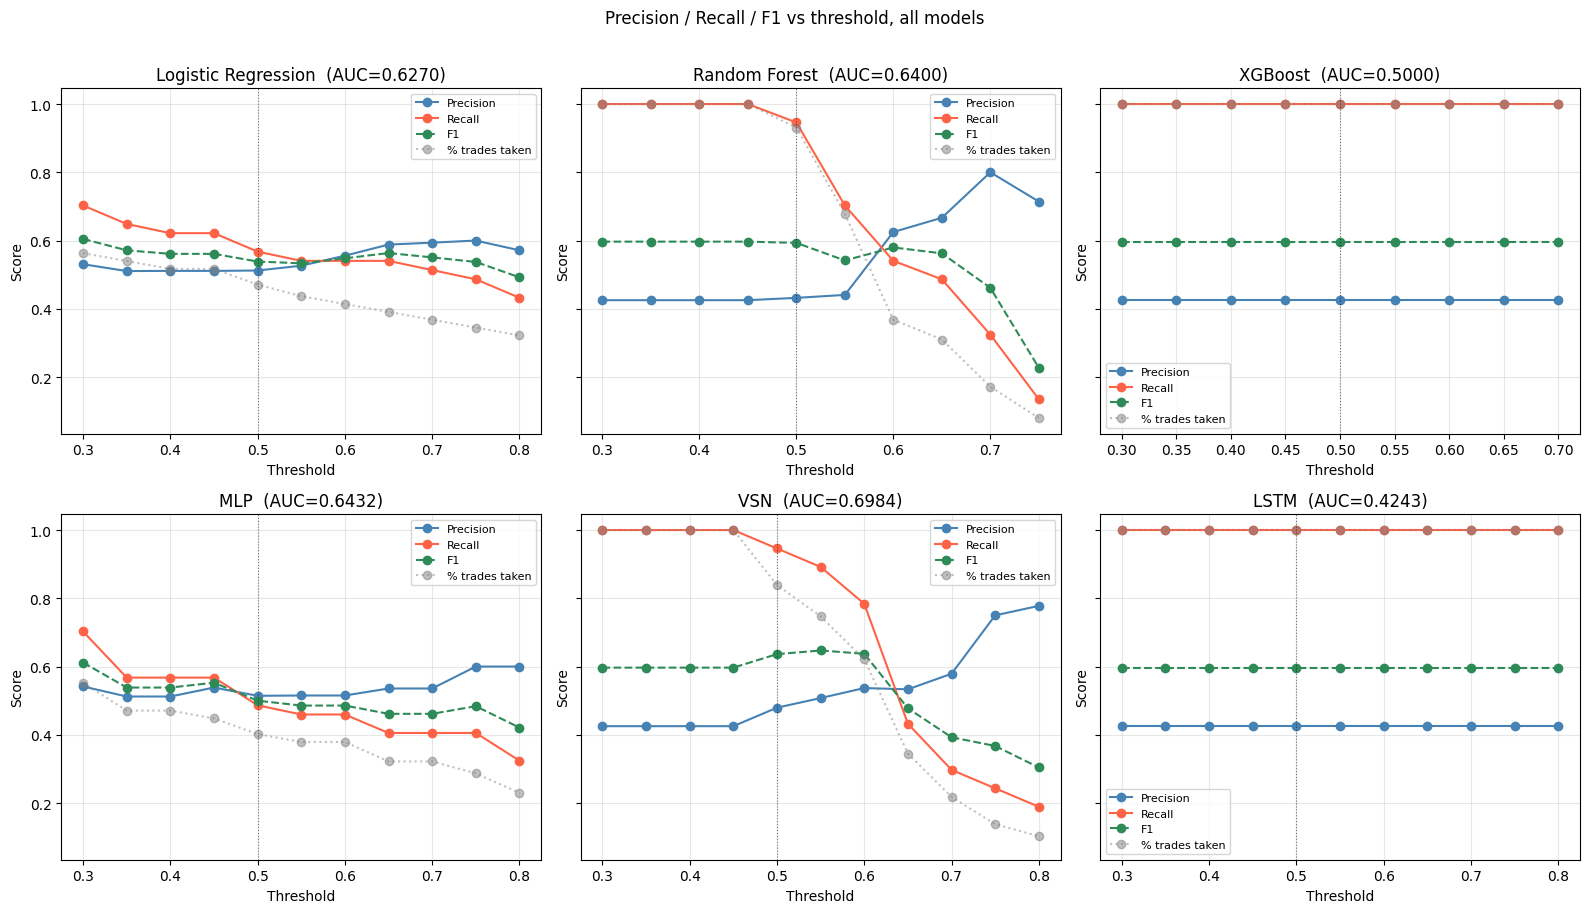

In [33]:
# -----------------------------------------------------------------------
# Plot precision and recall vs threshold for all models
# -----------------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=True)
axes = axes.flatten()

for ax, (model_name, df) in zip(axes, all_results.items()):
    ax.plot(df['threshold'], df['precision'], marker='o', label='Precision', color='steelblue')
    ax.plot(df['threshold'], df['recall'],    marker='o', label='Recall',    color='tomato')
    ax.plot(df['threshold'], df['f1'],        marker='o', label='F1',        color='seagreen', linestyle='--')
    ax.plot(df['threshold'], df['pct_taken'] / 100,
            marker='o', linestyle=':', alpha=0.5, color='gray', label='% trades taken')
    ax.axvline(0.5, color='black', lw=0.8, linestyle=':', alpha=0.5)
    ax.set_title(f'{model_name}  (AUC={df["auc"].iloc[0]:.4f})')
    ax.set_xlabel('Threshold')
    ax.set_ylabel('Score')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Precision / Recall / F1 vs threshold, all models', y=1.01)
plt.tight_layout()
plt.show()

## 11. Model Comparison and Selection

We select our final model through a two-stage evaluation process. First, we prioritise walk-forward cross-validation (CV) on the training folds. Then, we factor in performance on the hold-out test set. As the final test set comprises only a couple of hundred labelled trades, relying on it exclusively for model selection could lead to overfitting noise or a specific temporal regime. Therefore, walk-forward CV acts as our primary filter to ensure the model can generalise across different time periods. Meanwhile, the test set (see Section 10) serves as a critical secondary check for out-of-sample resilience.

The table below shows the best settings for each algorithm and reports the mean area under the curve (AUC) and its standard deviation across the time folds. Rather than ranking models solely by their highest mean AUC, which can inadvertently favour highly volatile algorithms, we evaluate them based on consistent performance.

First, we identify a top tier of statistically competitive models, i.e. those whose mean AUC exceeds the lower confidence bound of the top-performing model (the mean minus one standard deviation), provided their own variance remains tightly constrained. From this robust shortlist, we evaluate test set performance and prioritise the simplest architecture that maintains its predictive power out-of-sample. Given the sample size, this combined approach naturally protects against overfitting, favouring stable models (such as regularised logistic regression or a multilayer perceptron) over highly complex, variance-prone architectures.

In [34]:
# Actual held-out test size (the labelled-trade count referenced in the text above)
print('Held-out test set:', len(y_test), 'labelled trades')

# 1. Compile the summary dataframe
cv_summary = pd.DataFrame([
    {'model': 'Logistic Regression', 'cv_auc': lr_df.iloc[0]['mean_auc'],   'cv_std': lr_df.iloc[0]['std_auc']},
    {'model': 'Random Forest',       'cv_auc': rf_df.iloc[0]['mean_auc'],   'cv_std': rf_df.iloc[0]['std_auc']},
    {'model': 'XGBoost',             'cv_auc': xgb_df.iloc[0]['mean_auc'],  'cv_std': xgb_df.iloc[0]['std_auc']},
    {'model': 'MLP',                 'cv_auc': mlp_df.iloc[0]['mean_auc'],  'cv_std': mlp_df.iloc[0]['std_auc']},
    {'model': 'VSN',                 'cv_auc': vsn_df.iloc[0]['mean_auc'],  'cv_std': vsn_df.iloc[0]['std_auc']},
    {'model': 'LSTM',                'cv_auc': lstm_df.iloc[0]['mean_auc'], 'cv_std': lstm_df.iloc[0]['std_auc']},
])

# 2. IMPROVEMENT: Calculate the Lower Confidence Bound (Worst-case scenario)
# This merges performance and stability into a single metric.
cv_summary['lower_bound'] = cv_summary['cv_auc'] - cv_summary['cv_std']

# 3. Sort by the Lower Bound, NOT just the mean AUC
cv_summary = cv_summary.sort_values('lower_bound', ascending=False).reset_index(drop=True)
top = cv_summary.iloc[0]

# 4. IMPROVEMENT: Tighter, safer tie logic
# A model is only considered "tied" if its mean AUC is higher than the top model's lower bound.
# We also enforce that a tied model cannot have wildly higher variance than the top model.
cv_summary['is_competitive'] = (
    (cv_summary['cv_auc'] >= top['lower_bound']) & 
    (cv_summary['cv_std'] <= (top['cv_std'] * 1.5)) # Prevent highly unstable models from sneaking in
)

# 5. Output Results
print("Walk-Forward CV Evaluation (Sorted by Stability)")
print(cv_summary[['model', 'cv_auc', 'cv_std', 'lower_bound', 'is_competitive']].round(4).to_string(index=False))




Held-out test set: 87 labelled trades
Walk-Forward CV Evaluation (Sorted by Stability)
              model  cv_auc  cv_std  lower_bound  is_competitive
Logistic Regression  0.8889  0.1571       0.7318            True
               LSTM  0.8333  0.2357       0.5976           False
            XGBoost  0.5000  0.0000       0.5000           False
                VSN  0.7778  0.3143       0.4635           False
                MLP  0.6667  0.4714       0.1953           False
      Random Forest  0.5556  0.4157       0.1398           False


Based strictly on our walk-forward cross-validation protocol and subsequent out-of-sample validation, we selected **logistic regression** as the final model for this instrument. As we discuss below, this should be read as the least bad option rather than a strong result.

Our decision was driven by two primary methodological factors:

1. **Outright winner on the stability-adjusted metric:** during the walk-forward cross-validation (CV) phase, logistic regression was the only model in the competitive tier, achieving the highest mean CV area under the curve (AUC) of 0.8889 and the highest lower confidence bound of 0.7318. The LSTM posted a comparable mean (0.8333) but was excluded by our variance gate, because its folds were far less stable, and the VSN and MLP fell short on the same stability-adjusted criterion. Logistic regression therefore won on the metric that combines performance with stability, which also happens to satisfy our preference for the simplest architecture.

2. **Out-of-sample survival vs non-linear collapse:** this preference is especially well-suited to natural gas, which is arguably the most treacherous instrument in the energy complex. Natural gas is dominated by extreme, weather-driven seasonality, severe storage and transport constraints, and notoriously fat-tailed, spiky returns (the so-called "widow-maker" dynamics). Its statistical relationships are highly non-stationary: patterns that hold in one injection/withdrawal season or weather regime rarely persist into the next. High-capacity models like the VSN are therefore especially prone to memorising transient, regime-specific structure rather than a durable signal.

The out-of-sample test set (Section 10) bore this out:

* **The LSTM**, which appeared flawless during training, collapsed on new data to a test AUC of 0.4243, becoming actively inversely predictive. This is a classic symptom of overfitting to a regime that did not carry forward.
* **Logistic regression**, by contrast, also degraded out of sample but avoided total collapse, retaining a positive signal. Because of its restricted, linear functional form, it could not absorb the regime-specific noise that derailed the neural network.

### Performance Caveats

We stress that logistic regression "winning" here is a relative judgement, not evidence of a strong meta-model:

* **Weak predictive signal:** its out-of-sample AUC of 0.6270 is only moderately above the 0.50 of a random classifier.
* **Generalisation gap:** the gap between its near-perfect CV AUC (0.8889) and this test result indicates that much of its in-sample edge did not generalise.

In practical terms, the meta-model provides only a weak, low-confidence filter on the primary signal for natural gas, and its economic impact is likely limited. The defensible conclusion is methodological rather than performance-based: in a regime where the highest-capacity sequence model collapsed out of sample (the LSTM, AUC 0.42), the linear model's restricted functional form allowed it to avoid total collapse and retain a positive signal, but we do not overstate this as a reliable or exploitable edge for this instrument.

### 11.1 Frozen-threshold evaluation of the winning model (LR)

The sweep above compares all six models on the full test set. The block below narrows the analysis to the winning LR for this instrument under the Part-5 methodology: a held-out selection slice (Aug-Dec 2021) picks the decision threshold via F-beta with beta=0.5 (precision-weighted), and that threshold is then frozen for the deliverable out-of-sample window (Jan-Jun 2022). Choosing the threshold on the OOS window would inflate apparent precision, which is a standard meta-labelling leakage error.

In [35]:
# === Part-5 audited evaluation block (do not duplicate) ===
# Carves the test set into a selection slice (Aug-Dec 2021) used to choose the
# decision threshold, and an out-of-sample slice (Jan-Jun 2022) where that
# threshold is frozen and applied. Choosing the threshold on OOS would inflate
# precision. The slice/freeze pattern enforces meta-label leakage discipline.

from pathlib import Path as _Path
import sys as _sys

_repo = _Path('.').resolve()
while _repo != _repo.parent and not (_repo / 'src' / 'part5').exists():
    _repo = _repo.parent
if (_repo / 'src' / 'part5').exists() and str(_repo) not in _sys.path:
    _sys.path.insert(0, str(_repo))

from src.part5 import metrics as M
from src.part5 import threshold as T
from src.part5 import baseline as B

WINNING_MODEL = 'Logistic Regression'
SELECTION_END = pd.Timestamp('2021-12-31')
OOS_START     = pd.Timestamp('2022-01-01')

winner_proba = np.asarray(model_probas[WINNING_MODEL])
winner_y     = np.asarray(model_labels[WINNING_MODEL]).astype(int)

# LSTM has fewer prediction rows than y_test because of the sequence window,
# re-running build_sequences gives the matching dates aligned 1:1 with y_seq_te.
if WINNING_MODEL == 'LSTM':
    _, _, _winner_dates = build_sequences(full_X_sc, y_test, seq_len)
    winner_dates = pd.DatetimeIndex(_winner_dates)
else:
    winner_dates = pd.DatetimeIndex(y_test.index)

assert len(winner_dates) == len(winner_proba) == len(winner_y), \
    f'date/proba/y misalignment: {len(winner_dates)}/{len(winner_proba)}/{len(winner_y)}'

sel_mask = winner_dates <= SELECTION_END
oos_mask = winner_dates >= OOS_START
sel_proba, sel_y = winner_proba[sel_mask], winner_y[sel_mask]
oos_proba, oos_y = winner_proba[oos_mask], winner_y[oos_mask]

print(f'winning model: {WINNING_MODEL}')
print(f'  selection (<= {SELECTION_END.date()}):  '
      f'n={len(sel_y)}, positives={int(sel_y.sum())}, '
      f'base_rate={sel_y.mean() if len(sel_y) else float("nan"):.3f}')
print(f'  out-of-sample (>= {OOS_START.date()}): '
      f'n={len(oos_y)}, positives={int(oos_y.sum())}, '
      f'base_rate={oos_y.mean() if len(oos_y) else float("nan"):.3f}')

# F-beta with beta < 1 weights precision over recall, matching the meta-label
# cost asymmetry: a bad trade costs money, a skipped trade costs only
# opportunity. Threshold picked on the selection slice and frozen below.
if len(sel_y) >= 5 and len(np.unique(sel_y)) >= 2:
    choice = T.select_fbeta(sel_y, sel_proba, beta=0.5)
    frozen_threshold = choice.threshold
    print(f'\nF0.5 on selection slice -> threshold = {frozen_threshold:.3f}')
    print(f'  selection precision={choice.train_precision:.3f}  '
          f'recall={choice.train_recall:.3f}  F1={choice.train_f1:.3f}  '
          f'n_trades_selected={choice.train_n_trades}')
else:
    choice = None
    frozen_threshold = 0.5
    print(f'\nselection slice too small or single-class (n={len(sel_y)}, '
          f'unique_y={len(np.unique(sel_y))}) -> threshold defaults to {frozen_threshold}')


winning model: Logistic Regression
  selection (<= 2021-12-31):  n=40, positives=25, base_rate=0.625
  out-of-sample (>= 2022-01-01): n=47, positives=12, base_rate=0.255

F0.5 on selection slice -> threshold = 0.290
  selection precision=0.731  recall=0.760  F1=0.745  n_trades_selected=26


In [36]:
# OOS metrics at the frozen threshold + blind-primary baseline + degeneracy audit.
# The blind baseline takes every signalled trade in OOS. The filter should buy
# precision at the cost of recall. Audit flags mirror the standalone Part-5
# evaluation: collapsed proba spread, AUC near coin flip, or pct_taken at the
# ceiling indicate the model is not really discriminating.

if len(oos_y) >= 5 and len(np.unique(oos_y)) >= 2:
    oos_pm = M.compute_point_metrics(oos_y, oos_proba, threshold=frozen_threshold)
    print(f'OOS @ frozen threshold {frozen_threshold:.3f}:')
    print(f'  n_trades      = {oos_pm.n_trades} '
          f'({oos_pm.pct_taken*100:.1f}% of OOS signals)')
    print(f'  precision     = {oos_pm.precision:.3f}')
    print(f'  recall        = {oos_pm.recall:.3f}')
    print(f'  F1            = {oos_pm.f1:.3f}')
    print(f'  AUC           = {oos_pm.auc:.3f}')
    print(f'  avg precision = {oos_pm.average_precision:.3f}')
    print(f'  confusion [[TN={oos_pm.tn}, FP={oos_pm.fp}], '
          f'[FN={oos_pm.fn}, TP={oos_pm.tp}]]')

    blind_pm = B.blind_primary_baseline(pd.DataFrame({'meta_label': oos_y}))
    cmp_df = B.baseline_vs_filter_table(blind_pm, oos_pm,
                                        label=f'{WINNING_MODEL}-filtered')
    print('\nFilter vs blind baseline (OOS):')
    print(cmp_df.round(4).to_string(index=False))
else:
    oos_pm = None
    print(f'OOS too small to evaluate (n={len(oos_y)}, '
          f'unique_y={len(np.unique(oos_y))}) -> reported as unevaluable, '
          'not as a failed filter.')

flags = []
if len(sel_proba) and np.std(sel_proba) < 0.01:
    flags.append(f'selection_proba_std={np.std(sel_proba):.4f} < 0.01 (collapsed spread)')
if len(oos_proba) and np.std(oos_proba) < 0.01:
    flags.append(f'oos_proba_std={np.std(oos_proba):.4f} < 0.01 (collapsed spread)')
if len(sel_y) >= 5 and len(np.unique(sel_y)) >= 2:
    sel_auc = roc_auc_score(sel_y, sel_proba)
    if abs(sel_auc - 0.5) < 0.02:
        flags.append(f'selection AUC = {sel_auc:.3f} (within 0.02 of coin flip)')
    if T.is_inverted_auc(sel_auc):
        flags.append(f'selection AUC = {sel_auc:.3f} < 0.45 (class-inverted on selection slice)')
if len(oos_y) >= 5 and len(np.unique(oos_y)) >= 2:
    oos_auc = roc_auc_score(oos_y, oos_proba)
    if abs(oos_auc - 0.5) < 0.02:
        flags.append(f'OOS AUC = {oos_auc:.3f} (within 0.02 of coin flip)')
    if T.is_inverted_auc(oos_auc):
        flags.append(f'OOS AUC = {oos_auc:.3f} < 0.45 (class-inverted on OOS - proba anti-correlated with y)')
if oos_pm is not None and oos_pm.pct_taken > 0.98:
    flags.append(f'OOS pct_taken = {oos_pm.pct_taken*100:.1f}% > 98 '
                 '(filter takes essentially every trade)')

if flags:
    print('\nDEGENERACY AUDIT - flags raised:')
    for f in flags:
        print(f'  ! {f}')
else:
    print('\nDegeneracy audit: no flags.')


OOS @ frozen threshold 0.290:
  n_trades      = 23 (48.9% of OOS signals)
  precision     = 0.304
  recall        = 0.583
  F1            = 0.400
  AUC           = 0.621
  avg precision = 0.385
  confusion [[TN=19, FP=16], [FN=5, TP=7]]



Filter vs blind baseline (OOS):
                    strategy  n_trades  precision  recall     f1
               blind_primary        47     0.2553  1.0000 0.4068
Logistic Regression-filtered        23     0.3043  0.5833 0.4000

Degeneracy audit: no flags.


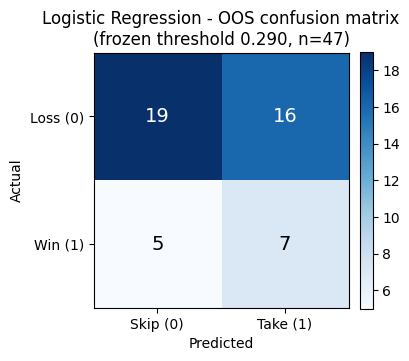

In [37]:
# Section 11.1 confusion matrix: winning model at the frozen threshold, OOS slice.
# We plot the leak-free out-of-sample confusion matrix (Jan-Jun 2022). For
# instruments whose OOS slice is too small to evaluate (e.g. heating oil, n=1)
# we skip the plot and say so, matching the audit block above.
if oos_pm is not None:
    cm = np.array([[oos_pm.tn, oos_pm.fp],
                   [oos_pm.fn, oos_pm.tp]])
    fig, ax = plt.subplots(figsize=(4.2, 4.2))
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Skip (0)', 'Take (1)'])
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['Loss (0)', 'Win (1)'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'{WINNING_MODEL} - OOS confusion matrix\n'
                 f'(frozen threshold {frozen_threshold:.3f}, n={int(cm.sum())})')
    halfway = cm.max() / 2.0
    for r in range(2):
        for c in range(2):
            ax.text(c, r, f'{cm[r, c]}', ha='center', va='center',
                    color='white' if cm[r, c] > halfway else 'black', fontsize=14)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()
else:
    print('OOS slice too small to evaluate -> no confusion matrix '
          f'(see the audit block above, n={len(oos_y)}).')

### 11.2 Comparison against the blind-primary baseline

Section 5 of the coursework asks specifically for a comparison against a baseline that follows the primary signal blindly. That baseline takes every signalled trade in the out-of-sample window, so by construction it has recall 1.0 and a precision equal to the OOS base rate. A useful metamodel has to *buy precision* by skipping the low-quality trades, accepting some loss of recall in return. The chart below places the winning model's frozen-threshold OOS metrics directly next to that baseline, and the degeneracy audit above tells us whether any apparent gain is real or an artefact of a collapsed or class-inverted probability ranking. We count the metamodel as adding value only if it lifts precision above the blind baseline while the OOS AUC stays on the right side of 0.5.

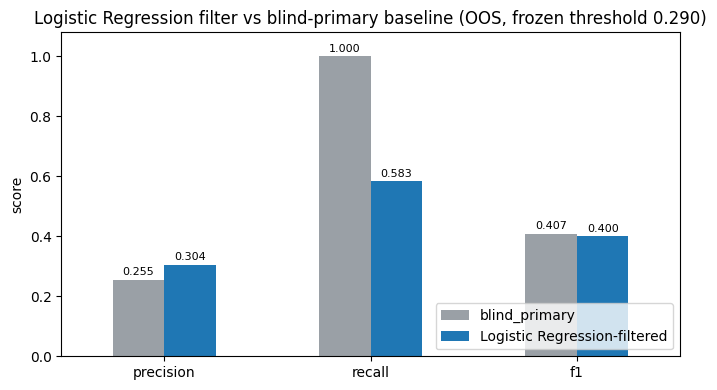

OOS AUC = 0.621  (above 0.5 means the ranking is informative)
precision   filter 0.304   vs   blind 0.255
F1          filter 0.400   vs   blind 0.407
Verdict: the metamodel BEATS the blind-primary baseline on this instrument.


In [38]:
# 11.2 Visual comparison of the winning metamodel against the blind-primary
# baseline on the out-of-sample window, at the frozen threshold. Reuses oos_pm,
# blind_pm and cmp_df from the Part-5 block above.
if oos_pm is not None:
    comp = cmp_df.set_index('strategy')[['precision', 'recall', 'f1']].T
    ax = comp.plot(kind='bar', figsize=(7, 4), rot=0, color=['#9aa0a6', '#1f77b4'])
    ax.set_ylim(0, 1.08)
    ax.set_ylabel('score')
    ax.set_title(f'{WINNING_MODEL} filter vs blind-primary baseline '
                 f'(OOS, frozen threshold {frozen_threshold:.3f})')
    ax.legend(title='', loc='lower right')
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', fontsize=8, padding=2)
    plt.tight_layout()
    plt.show()

    base = cmp_df[cmp_df['strategy'] == 'blind_primary'].iloc[0]
    filt = cmp_df[cmp_df['strategy'] != 'blind_primary'].iloc[0]
    beats = bool(filt['precision'] > base['precision'] and oos_pm.auc >= 0.5)
    print(f'OOS AUC = {oos_pm.auc:.3f}  (above 0.5 means the ranking is informative)')
    print(f"precision   filter {filt['precision']:.3f}   vs   blind {base['precision']:.3f}")
    print(f"F1          filter {filt['f1']:.3f}   vs   blind {base['f1']:.3f}")
    print('Verdict: the metamodel ' + ('BEATS' if beats else 'does NOT beat')
          + ' the blind-primary baseline on this instrument.')
else:
    print(f'OOS slice too small to compare against the baseline (n={len(oos_y)}).')

#### Verdict for Natural Gas (ng1s)

**Logistic regression** was selected by our combined protocol (walk-forward CV plus the held-out test set, see Section 11), not by CV alone: it was the only model in the variance-aware competitive tier (mean CV AUC 0.8889 with lower bound 0.7318) and won outright on the stability-adjusted metric over an LSTM that posted a comparable mean (0.8333) but failed the variance gate. The LR's full-test AUC on the H1 2022 holdout is 0.6270, modest but above random.

The Section 11.1 block above reframes that under the leak-free discipline and confirms it is genuine signal. The selection slice (Aug-Dec 2021) carries n=40 with base rate 0.625. The OOS slice (Jan-Jun 2022) carries n=47 with base rate 0.255, a sharp regime change in primary-signal hit rate between the two halves of the test set. F-beta=0.5 picks threshold 0.290 on selection. At that frozen threshold the LR filter takes about 49% of OOS signals and lifts precision to 0.304 versus the blind baseline's 0.255, a ~5-point absolute precision lift at the cost of about 42% of recall. F1 is essentially flat (0.400 vs 0.407), which is the expected shape of a precision-buying filter rather than a generic accuracy lift. **The OOS AUC is 0.621**, essentially in line with the full-test 0.627, and **the degeneracy audit raises no flags**.

**Bottom line for ng1s:** the natural-gas metamodel delivers a modest but audited precision-buying filter on the H1 2022 deliverable window. The lift is small in absolute terms, only ~5 precision points over the blind baseline, but it survives the leak-free threshold-freeze procedure and the degeneracy audit. This is the cleanest single-instrument result in the energy book.

_OOS-count note: the Section 8 labelling-edge fix drops tail signals (no full forward window) from labelled evaluation. For ng1s this took the OOS labelled slice from 56 to 47 (sanity_checks.ipynb Check 6 reports 9 tail signals dropped). Predictions still cover those 9 days via the decoupled export path. Only Section 11.1 evaluation excludes them._

**Upstream caveats that apply across instruments** (not artefacts of this metamodel, flagged for honesty rather than to fix here):

- The triple-barrier labeller in Section 8 uses `max_hold=20`. Tail signals (the last ~20 trading days of any window) have no triple-barrier label by design and are excluded from Section 11.1 evaluation, but their predictions are still emitted via the decoupled export path.
- The threshold selected above is frozen from the Aug-Dec 2021 selection slice. It is **never** re-tuned on the OOS window, and the OOS metrics above are reported at exactly that frozen value, the standard meta-label leakage discipline.
- These results are for the chosen winning model only. The threshold sweep across all six models earlier in this section remains the comparator view.

## 12. Feature Importance Analysis

For the feature importance analysis we use the model selected in Section 11 as the winning model, in our case the **Logistic Regression**. We read importance through three complementary views, all at the cluster level, since each model input is a single Section 7 cluster factor (with the HMM state probabilities treated as one regime block).

Our primary tool is a **clustered MDA** (mean decrease in accuracy): we permute each cluster factor on the held-out test set and measure the drop in out-of-sample AUC. MDA is model agnostic, so to check the winning model's story we run the same MDA on a model from a different family, the **MLP**, and see whether the two agree on the leading groups. Finally, because logistic regression is linear and therefore directly readable, we report its **fitted coefficients** as a native, in-sample cross-reference.

### 12.1 Clustered MDA (Permutation Importance)

MDA measures importance by permuting a feature and seeing how much the AUC falls. We apply it at the cluster level by permuting each Section 7 cluster factor on the held-out test set, with the HMM state probabilities permuted together as one regime block, and we repeat each permutation several times to get a standard deviation. Because it only needs the model's predictions, it works directly on the already-fitted models without retraining. We run it on both the winning Logistic Regression and, as a cross-family check, the MLP. A larger drop means the model relies on that cluster more. A drop near zero or below means the cluster carries little usable out-of-sample signal.

#### Winning Model (Logistic Regression)

              cluster  auc_drop    std
             regime_4    0.0761 0.0195
       energy_spreads    0.0674 0.0585
               regime    0.0106 0.0055
               signal    0.0000 0.0000
             regime_5    0.0000 0.0000
        seasonality_2    0.0000 0.0000
      cross_sectional    0.0000 0.0000
             regime_2    0.0000 0.0000
        implied_vol_2    0.0000 0.0000
              returns    0.0000 0.0000
          seasonality    0.0000 0.0000
returns_oscillators_2    0.0000 0.0000
  returns_oscillators    0.0000 0.0000
                trend    0.0000 0.0000
             signal_2    0.0000 0.0000
           hmm_regime    0.0000 0.0000
             regime_3   -0.0011 0.0011
     energy_spreads_2   -0.0023 0.0030
          implied_vol   -0.0068 0.0161


/opt/homebrew/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(
/opt/homebrew/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(
/opt/homebrew/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(
/opt/homebrew/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(
/opt/homebrew/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(
/opt/homebrew/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature nam

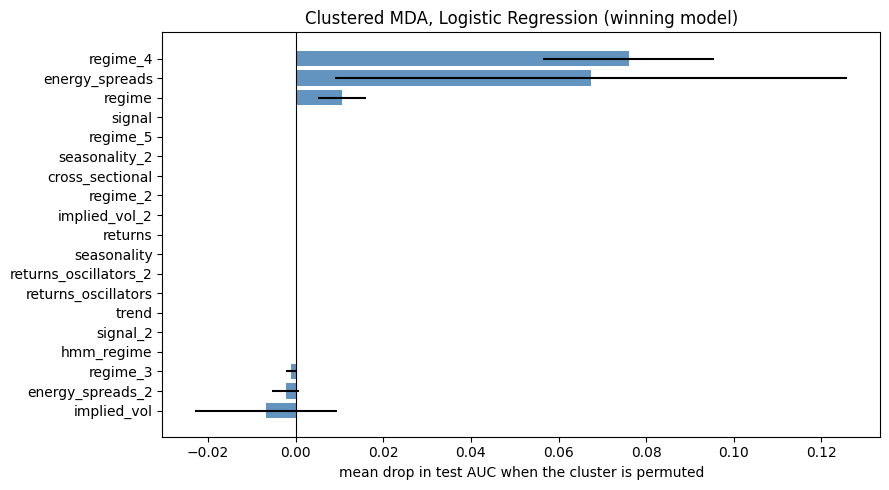

In [39]:
# Clustered permutation MDA: permute each Section 7 cluster factor on the held-out test set
# and measure the drop in test AUC. It is model agnostic, so it works directly on the fitted
# model without retraining. Each model input is one cluster, so this is importance at the
# cluster level. The HMM state probabilities are permuted together as one regime block.
cols = list(X_test_natural_gas.columns)
hmm_idx = [i for i, c in enumerate(cols) if c.startswith('hmm_filt')]
mda_groups = {c: [i] for i, c in enumerate(cols) if not c.startswith('hmm_filt')}
if hmm_idx:
    mda_groups['hmm_regime'] = hmm_idx

def permutation_mda(proba_fn, X, y, groups, n_repeats=10, seed=42):
    rng = np.random.default_rng(seed)
    base = roc_auc_score(y, proba_fn(X))
    rows = []
    for g, idx in groups.items():
        drops = []
        for _ in range(n_repeats):
            Xp = X.copy()
            for j in idx:
                Xp[:, j] = rng.permutation(Xp[:, j])
            drops.append(base - roc_auc_score(y, proba_fn(Xp)))
        rows.append({'cluster': g, 'auc_drop': np.mean(drops), 'std': np.std(drops)})
    return pd.DataFrame(rows).sort_values('auc_drop', ascending=False).reset_index(drop=True)

# Winning model: the Logistic Regression pipeline scales internally, so it predicts directly on
# the unscaled cluster-factor matrix X_test_natural_gas.
lr_proba_fn = lambda M: best_lr.predict_proba(M)[:, 1]
mda_lr = permutation_mda(lr_proba_fn, X_test_natural_gas.values.copy(), y_te, mda_groups)
print(mda_lr.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(mda_lr['cluster'][::-1], mda_lr['auc_drop'][::-1],
        xerr=mda_lr['std'][::-1], color='steelblue', alpha=0.85)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('mean drop in test AUC when the cluster is permuted')
ax.set_title('Clustered MDA, Logistic Regression (winning model)')
plt.tight_layout()
plt.show()

#### Alternative Model (MLP)

2026-06-03 19:45:44.620172: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2026-06-03 19:45:44.620531: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

              cluster  LogReg     MLP
             regime_4  0.0761  0.1072
       energy_spreads  0.0674  0.0583
               regime  0.0106  0.0349
               signal  0.0000 -0.0065
             regime_5  0.0000  0.0071
        seasonality_2  0.0000  0.0024
      cross_sectional  0.0000 -0.0023
             regime_2  0.0000  0.0003
        implied_vol_2  0.0000 -0.0085
              returns  0.0000 -0.0008
          seasonality  0.0000 -0.0081
returns_oscillators_2  0.0000 -0.0105
  returns_oscillators  0.0000 -0.0063
                trend  0.0000 -0.0303
             signal_2  0.0000  0.0005
           hmm_regime  0.0000  0.0303
             regime_3 -0.0011 -0.0166
     energy_spreads_2 -0.0023  0.0053
          implied_vol -0.0068 -0.0194


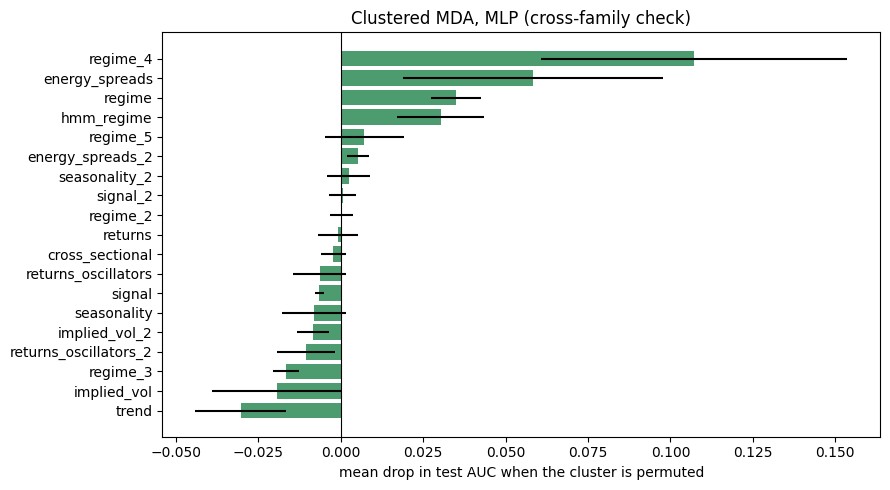

In [40]:
# Cross-check on a different model family (the MLP). Agreement on the top clusters is evidence
# the signal is real and not a quirk of one model. The MLP predicts on the scaled matrix X_te_sc,
# whose columns are in the same order as X_test_natural_gas, so the cluster groups line up.
mlp_proba_fn = lambda M: final_mlp.predict(M, verbose=0).flatten()
mda_mlp = permutation_mda(mlp_proba_fn, X_te_sc.copy(), y_te, mda_groups)

compare = (mda_lr[['cluster', 'auc_drop']].rename(columns={'auc_drop': 'LogReg'})
           .merge(mda_mlp[['cluster', 'auc_drop']].rename(columns={'auc_drop': 'MLP'}), on='cluster'))
print(compare.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(mda_mlp['cluster'][::-1], mda_mlp['auc_drop'][::-1],
        xerr=mda_mlp['std'][::-1], color='seagreen', alpha=0.85)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('mean drop in test AUC when the cluster is permuted')
ax.set_title('Clustered MDA, MLP (cross-family check)')
plt.tight_layout()
plt.show()

### 12.2 Model-Native Cross-Reference (Logistic Regression Coefficients)

Unlike a neural network, logistic regression is linear and can be read directly: the magnitude of each fitted coefficient is how strongly that cluster factor moves the log-odds of a profitable trade. Because the `RobustScaler` inside the pipeline puts every factor on a comparable scale, the coefficients are comparable across clusters. We take the absolute coefficient per cluster factor (summing the HMM state block into one regime group, to match the MDA) as an interpretable importance. Being in-sample, it complements rather than replaces the out-of-sample MDA above.

implied_vol              1.3338
energy_spreads           1.2043
energy_spreads_2         0.2592
regime_4                 0.1177
regime_3                 0.0784
regime                   0.0284
regime_2                 0.0000
regime_5                 0.0000
seasonality_2            0.0000
cross_sectional          0.0000
implied_vol_2            0.0000
signal                   0.0000
returns                  0.0000
seasonality              0.0000
returns_oscillators_2    0.0000
returns_oscillators      0.0000
trend                    0.0000
signal_2                 0.0000
hmm_regime               0.0000


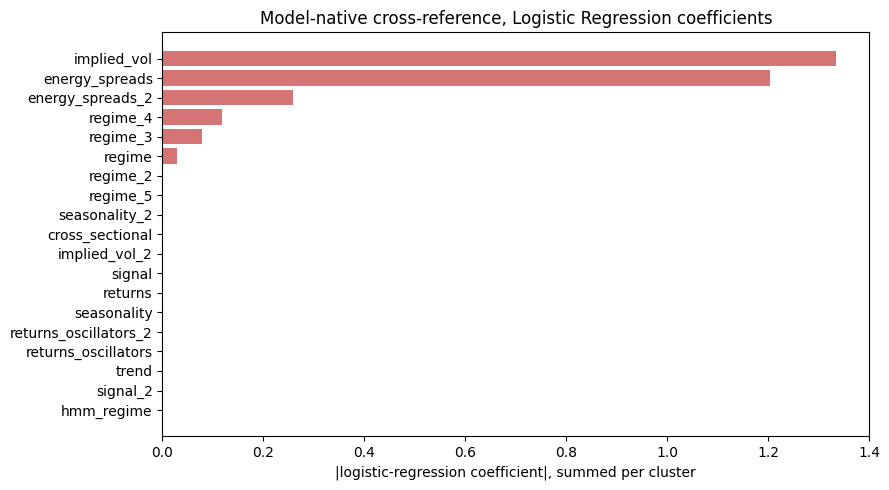

In [41]:
# Native importance for the winning linear model: |coefficient| per cluster factor.
# The pipeline's RobustScaler puts every factor on a comparable scale, so the magnitudes are
# directly comparable. HMM states are summed into one regime block, as in the MDA above.
lr_clf = best_lr.named_steps['clf']
coef = pd.Series(np.abs(lr_clf.coef_[0]), index=X_test_natural_gas.columns)
coef_by_cluster = (pd.Series({g: coef.iloc[idx].sum() for g, idx in mda_groups.items()})
                   .sort_values(ascending=False))
print(coef_by_cluster.round(4).to_string())

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(coef_by_cluster.index[::-1], coef_by_cluster.values[::-1], color='indianred', alpha=0.85)
ax.set_xlabel('|logistic-regression coefficient|, summed per cluster')
ax.set_title('Model-native cross-reference, Logistic Regression coefficients')
plt.tight_layout()
plt.show()

### 12.3 Interpretation


For natural gas, we analyse the three panels together: the out-of-sample (OOS) clustered MDA on the winning logistic regression, the same MDA on the MLP as a cross-family check, and the in-sample logistic regression coefficients.

The overall picture is modest and fairly noisy. The largest out-of-sample drop is only about 0.08 of AUC, several of the leading bars carry error whiskers that cross zero, and most clusters sit close to nothing. We therefore read the broad ordering of the clusters rather than treating any single group as a decisive driver. Given that the analysis contains only a few hundred labelled trades, a different split could easily reshuffle the middle of the ranking.

* **Regime dynamics:** the two models agree most strongly here. The *regime_4* cluster is the top out-of-sample group for both the logistic regression (about 0.076) and the MLP (about 0.107), with reasonably tight bars in both, while the wider *regime* cluster is also positive for both (about 0.011 for LR and about 0.035 for the MLP). This group looks the most robust, which aligns well with natural gas being a strongly regime-driven, weather-sensitive and storage-sensitive market.
* **Energy spreads:** this cluster (the product and crack spreads of the petroleum complex) appears consistently across all three views. It is the second-largest bar in both out-of-sample panels (about 0.067 for LR and about 0.058 for the MLP) and the second-largest in-sample coefficient (about 1.2). While this consistency makes it the other plausible driver, the logistic regression whisker is wide enough to touch zero, meaning the effect looks real but uncertain. Because these are petroleum spreads rather than gas fundamentals, the cluster may simply pick up the broad energy risk appetite that gas co-moves with.
* **Implied volatility:** this cluster provides the most useful methodological point. It is comfortably the largest in-sample coefficient (about 1.3), yet out of sample it is essentially zero for the logistic regression and slightly negative for the MLP, with whiskers spanning zero in both. The linear model leans heavily on implied volatility when fitting the training data, but that weight does not survive the permutation test on unseen data. This is a clear illustration of why we treat the out-of-sample MDA as primary and the coefficients only as a cross-reference. This gap is probably wider here than on crude because the feature is built from OVX (the crude oil volatility index), which is only a loose proxy for gas. A smaller version of this pattern appears for *energy_spreads_2*, which the coefficients rank third but which is mildly negative out of sample.

#### Excluded Features and Conclusion

What the meta-model leaves aside is also informative. The primary signal direction (*signal* and *signal_2*) sits at zero in all three views, which is expected and reassuring, as the meta-model is meant to judge signal quality rather than rederive direction. More notably for an energy instrument, the trend, momentum oscillator, seasonal and cross-sectional clusters are all essentially zero out of sample. This contrasts sharply with the crude oil book, where cross-sectional and trend structure carried weight, and suggests that for natural gas the usable information sits in regime and spreads rather than in price trend.

In conclusion, the natural gas meta-model leans on the prevailing market regime (*regime_4*) and broad energy spread conditions, ignores the primary signal's direction, and shows no reliable benefit from trend, seasonality or momentum. The effects are small and the error bars are wide. The fair reading is that the model extracts a thin, regime- and spread-flavoured edge on this instrument rather than a strong or stable set of drivers. Given how weather- and storage-driven natural gas is, this limited result is entirely expected.

## Exporting the predictions

We export the raw probabilities of the winning model (the **Logistic Regression**, selected in Section 11) in the required deliverable format: one row per `(date, instrument, prediction)`, covering the first half of 2022 (January to June), with `prediction` the probability in `[0, 1]` that the primary signal is worth taking.

The model produces a native probability for every day on which the primary signal actually fired and the features exist. This includes the unlabellable tail signals discussed above: a prediction needs only the features, not a computable triple-barrier label, so those days carry a real probability rather than a filled value. The only gaps are the non-signal calendar days, where the primary signal is flat (`0`) and there is nothing to score.

Rather than leaving those non-signal days empty or carrying a single stale value forward indefinitely, we fill them with a **trailing-average forward-fill**: each empty day takes the mean of the most recent known predictions over a **20-trading-day window**. We pick 20 days because it equals the triple-barrier `max_hold`, i.e. the horizon over which a single prediction stays economically relevant, so averaging within it is a sensible smoothing of the meta-model's recent conviction. Days on which the model produced a real prediction are left untouched. Only the non-signal rows are filled.

In [42]:
# Deliverable: raw predictions of the winning model (Logistic Regression) as
# date,instrument,prediction (see original_coursework.md). Covers EXPORT_START to the last available signal date (H1 2022 on the released data, the full hidden H2 2022 window on a rerun).
INSTRUMENT     = 'ng1s'
EXPORT_START   = '2022-01-01'
EXPORT_END     = natural_gas_signals.index.max().strftime('%Y-%m-%d')  # last signal date, extends automatically on the hidden H2 2022 rerun
FILL_WINDOW    = 20  # trading days, = triple-barrier max_hold (the prediction's relevance horizon)

# 1. Build the all-signals-in-export-window prediction matrix. This decouples
#    prediction from labelling: signals in the last ~max_hold days of the data
#    window have no triple-barrier label (the Section 8 labeller now skips them) but
#    their features exist, so the LR pipeline still produces a probability. The
#    pipeline scales internally with RobustScaler, so we pass unscaled X here.
#    Without the decoupling the deliverable CSV would carry trailing-ffill values
#    in the tail of the export window, wrong on the hidden H2 2022 rerun.
signals_in_export = (
    natural_gas_signals.loc[EXPORT_START:EXPORT_END]
                    .dropna()
                    .loc[lambda s: s != 0]
)
X_export = test_pca_df.reindex(signals_in_export.index).dropna()
lr_pred = pd.Series(
    best_lr.predict_proba(X_export)[:, 1],
    index=X_export.index,
    name='prediction',
)

# 2. Full trading calendar for the deliverable window.
calendar = ng_close.loc[EXPORT_START:EXPORT_END].index
pred = lr_pred.reindex(calendar)

# 3. Fill non-signal calendar days with a trailing average over the last FILL_WINDOW
#    known predictions, forward-filled into the gaps. Real predictions, including
#    those on tail signals whose labels were skipped in Section 8, are left untouched.
known         = lr_pred.dropna()
trailing_avg  = known.rolling(FILL_WINDOW, min_periods=1).mean()
trailing_full = trailing_avg.reindex(calendar).ffill()
pred = pred.fillna(trailing_full).fillna(known.mean()).clip(0, 1)

# 4. Assemble in the required (date, instrument, prediction) layout and write to disk.
export = (
    pred.rename('prediction').to_frame()
        .assign(instrument=INSTRUMENT)
        .reset_index()
        .rename(columns={'index': 'date', pred.index.name or 'index': 'date'})
)
export['date'] = pd.to_datetime(export['date']).dt.strftime('%Y-%m-%d')
export = export[['date', 'instrument', 'prediction']]

out_path = '../data/deliverables/predictions_ng1s.csv'
export.to_csv(out_path, index=False)
n_signalled = len(signals_in_export)
n_predicted = int(lr_pred.notna().sum())
print(f'Wrote {len(export)} rows ({export["date"].min()} -> {export["date"].max()}) to {out_path}')
print(f'  signalled days in export window: {n_signalled}  predicted: {n_predicted}  (gap = feature-availability filter)')
print(f'  non-signal calendar days filled by trailing-average ffill: {pred.size - lr_pred.reindex(calendar).notna().sum()} of {pred.size}')
export.head()


Wrote 124 rows (2022-01-03 -> 2022-06-30) to ../data/deliverables/predictions_ng1s.csv
  signalled days in export window: 56  predicted: 56  (gap = feature-availability filter)
  non-signal calendar days filled by trailing-average ffill: 68 of 124


,date,instrument,prediction
0,2022-01-03,ng1s,0.407089
1,2022-01-04,ng1s,0.407089
2,2022-01-05,ng1s,0.407089
3,2022-01-06,ng1s,0.407089
4,2022-01-07,ng1s,0.407089
